Deep Dive on certain high impact/volatile players to see if any inverse correlators exist within a subset of the players. It's possible this subset is masked/lost when looking at the population as a whole.

In [115]:
# Libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_ROOT = Path.cwd().parent.parent

plt.rcParams.update({'font.size': 18})

In [116]:
# Taken from Ani's implementation in player_level_twitter_correlation_analysis.py
def dcor(a, b):
    def cent_dist(v):
        d = np.abs(v[:, None] - v[None, :]).astype(float)
        return d - d.mean(1, keepdims=True) - d.mean(0, keepdims=True) + d.mean()
    A, B = cent_dist(a), cent_dist(b)
    denom = np.sqrt(abs((A * A).mean()) * abs((B * B).mean()))
    return np.sqrt(abs((A * B).mean()) / denom) if denom > 0 else 0.0

def correlate_series(xi, yi, min_n=10):
    """Return dict of correlation stats, or None if insufficient data."""
    mask = ~(np.isnan(xi) | np.isnan(yi))
    xi, yi = xi[mask], yi[mask]
    if len(xi) < min_n:
        return None
    r_p, p_p = stats.pearsonr(xi, yi)
    r_s, p_s = stats.spearmanr(xi, yi)
    dc       = dcor(xi, yi)
    return dict(
        n           = len(xi),
        pearson_r   = round(r_p, 4), pearson_p  = round(p_p, 4),
        spearman_r  = round(r_s, 4), spearman_p = round(p_s, 4),
        distance_cor= round(dc,  4),
        pearson_sig = "***" if p_p<0.001 else ("**" if p_p<0.01 else ("*" if p_p<0.05 else "")),
        spearman_sig= "***" if p_s<0.001 else ("**" if p_s<0.01 else ("*" if p_s<0.05 else "")),
    )

In [117]:
# Filter to players of interest
players = [
    'Jalen Hurts',
    'A.J. Brown',
    'Josh Allen',
    'Baker Mayfield',
    'Ja\'Marr Chase',
    'George Pickens',
    'Saquon Barkley',
    'James Cook',
    'Jonathan Taylor'    
]

twitter_df = pd.read_csv(PROJECT_ROOT / 'sentiment_indices' / 'twitter_local_index_sprint2.csv')
twitter_df = twitter_df.rename(columns={'local_index': 'sent_index'})
global_df = pd.read_csv(PROJECT_ROOT / 'sentiment_indices' / 'global_index.csv')
global_df = global_df.rename(columns={'player': 'subject', 'week': 'game_id', 'global_index': 'sent_index'})

twitter_df['subject'] = twitter_df['subject'].replace({'AJ Brown': 'A.J. Brown',
                                                       'JaMarr Chase': 'Ja\'Marr Chase'})
global_df['subject'] = global_df['subject'].replace({'AJ Brown': 'A.J. Brown',
                                                     'JaMarr Chase': 'Ja\'Marr Chase'})
stats_df = pd.read_csv(PROJECT_ROOT / 'data' / 'nfl_sentiment_2025_cleaned.csv')

twitter_df = twitter_df[twitter_df['subject'].isin(players)]
global_df = global_df[global_df['subject'].isin(players)]
stats_df = stats_df[stats_df['player_name'].isin(players)]

twitter_df['game_id'] = twitter_df.apply(
    lambda x: int(x['game_id'][1:]), axis=1
)
global_df['game_id'] = global_df.apply(
    lambda x: int(x['game_id'][1:]), axis=1
)


qb_cols = [
    'game_week',
    'stats_passing_pass_attempts',
    'stats_passing_pass_completions',
    'stats_passing_pass_yards',
    'stats_passing_pass_td',
    'stats_passing_pass_int',
    'stats_passing_qb_rating'
]

wr_cols = [
    'game_week',
    'stats_receiving_targets',
    'stats_receiving_receptions',
    'stats_receiving_rec_yards',
    'stats_receiving_rec_td'
]

rb_cols = [
    'game_week',
    'stats_rushing_rush_attempts',
    'stats_rushing_rush_yards',
    'stats_rushing_rush_td'
]

qb_stats_list = ['Pass Attempts', 'Completions', 'Pass Yards', 'Pass TDs', 'INTs', 'QB Rating']
wr_stats_list = ['Targets', 'Receptions', 'Rec Yards', ' Rec TDs']
rb_stats_list = ['Rush Attempts', 'Rush Yards', 'Rush TDs']

In [118]:
def get_dfs_for_player(player_name, cols):
    player_twitter_df = twitter_df[twitter_df['subject'] == player_name]
    player_global_df = global_df[global_df['subject'] == player_name]
    player_perf_df = stats_df[stats_df['player_name'] == player_name]
    player_perf_df = player_perf_df[cols]
    player_perf_df = player_perf_df[player_perf_df['game_week'] < 19]
    return player_twitter_df.sort_values(by='game_id'), player_global_df.sort_values(by='game_id'), player_perf_df.sort_values(by='game_week')

def standardize_cols(twitter_df, global_df, perf_df, cols):
    twitter_df['sent_index'] = (twitter_df['sent_index'] - np.mean(twitter_df['sent_index'])) / np.std(twitter_df['sent_index'])
    global_df['sent_index'] = (global_df['sent_index'] - np.mean(global_df['sent_index'])) / np.std(global_df['sent_index'])

    for col in cols:
        if col != 'game_week':
            perf_df[col] = (perf_df[col] - np.mean(perf_df[col])) / np.std(perf_df[col])

    return twitter_df, global_df, perf_df

def make_plot(std_sent_df, std_perf_df, player_name):
    plt.plot(std_sent_df['game_id'], std_sent_df['sent_index'], label='Sentiment')
    for col in std_perf_df.columns:
        if col != 'game_week':
            parts = col.split('_')[2:]
            lab = ''
            for s in parts:
                lab += s.capitalize() + ' '
            plt.plot(std_perf_df['game_week'], std_perf_df[col], alpha = 0.5, label=lab.strip())

    plt.xlabel('Week')
    plt.ylabel('Standardized Metric Value')
    plt.title(player_name + ' Std. Sentiment and Performance Metrics')
    plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])
    plt.legend()
    plt.show()

def get_corr_df(sent_df, perf_df, df_cols, col_labels, source):
    df_cols.remove('game_week')
    dicts = [correlate_series(sent_df['sent_index'].values.astype(float), perf_df[col].values.astype(float)) for col in df_cols]
    corr_df = pd.DataFrame({
        'Statistic': col_labels,
        source + ' Pearson': [d['pearson_r'] for d in dicts],
        source + ' Spearman': [d['spearman_r'] for d in dicts],
        source + ' Distance Corr': [d['distance_cor'] for d in dicts]
    })
    return corr_df

def make_lagged_plot(std_sent_lag_df, std_perf_lag_df, player_name):
    weeks = std_perf_lag_df['game_week'] - 1
    plt.plot(std_sent_lag_df['game_id'], std_sent_lag_df['sent_index'], label='Sentiment')
    for col in std_perf_lag_df.columns:
        if col != 'game_week':
            parts = col.split('_')[2:]
            lab = ''
            for s in parts:
                lab += s.capitalize() + ' '
            plt.plot(weeks, std_perf_lag_df[col], alpha = 0.5, label=lab.strip())

    plt.xlabel('Week Sentiment / Week + 1 Performance')
    plt.ylabel('Standardized Metric Value')
    plt.title(player_name + ' Std. Sentiment and Lagged Performance')
    plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])
    plt.legend()
    plt.show()

# Jalen Hurts

In [119]:
hurts_twitter_df, hurts_global_df, hurts_perf_df = get_dfs_for_player('Jalen Hurts', qb_cols)
hurts_twitter_df = hurts_twitter_df[hurts_twitter_df['game_id'] != 18]   # Hurts did not play W18
hurts_global_df = hurts_global_df[hurts_global_df['game_id'] != 18]   # Hurts did not play W18
hurts_global_df = hurts_global_df[hurts_global_df['game_id'] != 9]   # Eagles bye in W9
hurts_perf_df.head()

,game_week,stats_passing_pass_attempts,stats_passing_pass_completions,stats_passing_pass_yards,stats_passing_pass_td,stats_passing_pass_int,stats_passing_qb_rating
28,1,23,19,152,0,0,94.2
2665,2,22,15,101,0,0,78.0
3391,3,32,21,226,3,0,117.4
4946,4,24,15,130,2,0,104.5
6408,5,38,23,280,2,0,100.8


In [120]:
hurts_twitter_df_std, hurts_global_df_std, hurts_perf_df_std = standardize_cols(hurts_twitter_df, hurts_global_df, hurts_perf_df, qb_cols)

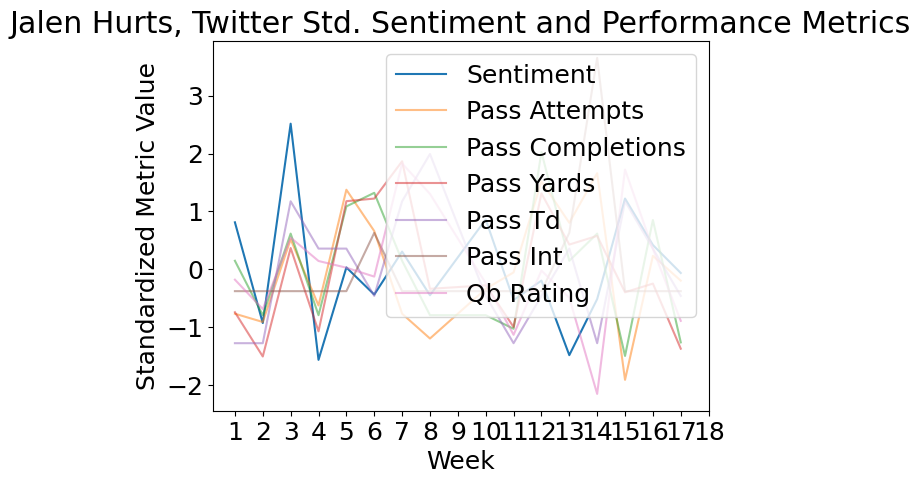

In [121]:
make_plot(hurts_twitter_df_std, hurts_perf_df_std, 'Jalen Hurts, Twitter')

Overall, looks like a somewhat positive correlation

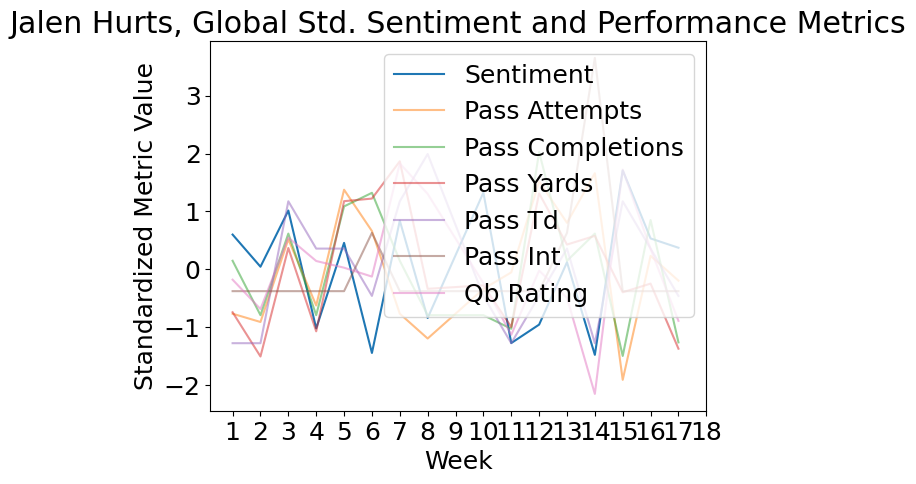

In [122]:
make_plot(hurts_global_df_std, hurts_perf_df_std, 'Jalen Hurts, Global')

In [123]:
hurts_twitter_corr_df = get_corr_df(hurts_twitter_df, hurts_perf_df, qb_cols.copy(), qb_stats_list, 'Twitter')
hurts_global_corr_df = get_corr_df(hurts_global_df, hurts_perf_df, qb_cols.copy(), qb_stats_list, 'Global')
hurts_corr_df = pd.merge(hurts_twitter_corr_df, hurts_global_corr_df, on='Statistic')
hurts_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,-0.1421,-0.1589,0.3621,-0.4195,-0.4224,0.3986
1,Completions,0.0654,0.0758,0.3275,-0.2678,-0.2216,0.3361
2,Pass Yards,0.1393,0.1971,0.3782,-0.0559,-0.0265,0.2943
3,Pass TDs,0.2713,0.3018,0.4394,0.3478,0.4451,0.4276
4,INTs,-0.2507,-0.3954,0.3834,-0.4561,-0.5186,0.4742
5,QB Rating,0.3894,0.4618,0.4967,0.4991,0.5029,0.4843


## Lagged Performance

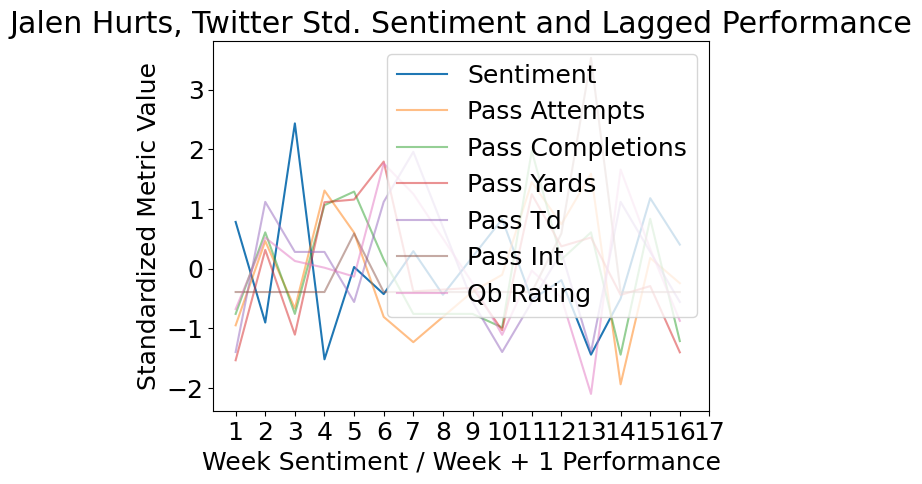

In [124]:
# Remove last row of sentiment and first row of performance
hurts_twitter_lag = hurts_twitter_df.iloc[:-1]
hurts_global_lag = hurts_global_df.iloc[:-1]
hurts_perf_lag = hurts_perf_df.iloc[1:]
hurts_twitter_lag_std, hurts_global_lag_std, hurts_perf_lag_std = standardize_cols(hurts_twitter_lag, hurts_global_lag, hurts_perf_lag, qb_cols)
make_lagged_plot(hurts_twitter_lag_std, hurts_perf_lag_std, 'Jalen Hurts, Twitter')

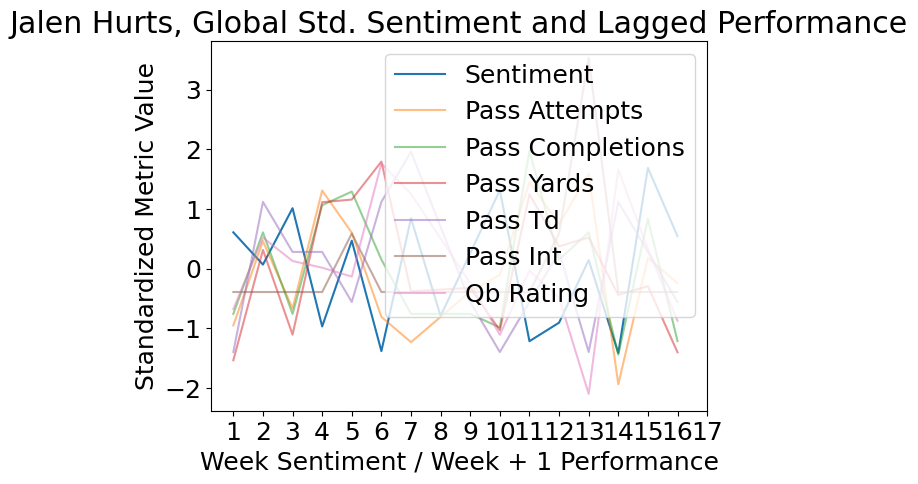

In [125]:
make_lagged_plot(hurts_global_lag_std, hurts_perf_lag_std, 'Jalen Hurts, Global')

In [126]:
hurts_twitter_corr_lag = get_corr_df(hurts_twitter_lag, hurts_perf_lag, qb_cols.copy(), qb_stats_list, 'Twitter')
hurts_global_corr_lag = get_corr_df(hurts_global_lag, hurts_perf_lag, qb_cols.copy(), qb_stats_list, 'Global')
hurts_corr_lag = pd.merge(hurts_twitter_corr_lag, hurts_global_corr_lag, on='Statistic')
hurts_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,-0.4527,-0.4607,0.5849,-0.0837,-0.1179,0.4137
1,Completions,-0.4032,-0.3989,0.5145,-0.1879,-0.1661,0.3696
2,Pass Yards,-0.6392,-0.6107,0.7082,-0.5921,-0.5607,0.6126
3,Pass TDs,-0.0593,-0.1282,0.3570,-0.2333,-0.2876,0.3833
4,INTs,-0.3879,-0.2251,0.4388,0.0087,-0.0716,0.2581
5,QB Rating,0.0283,-0.0929,0.4052,-0.3370,-0.3107,0.4573


In [127]:
hurts_corr_df['Statistic'] = hurts_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
hurts_corr_df = hurts_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

hurts_corr_lag['Statistic'] = hurts_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
hurts_corr_lag = hurts_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

hurts_corr_df = pd.concat([hurts_corr_df, hurts_corr_lag], ignore_index=True)
hurts_corr_df

,Statistic,Twitter Pearson,Global Pearson
0,Conc. Pass Attempts,-0.1421,-0.4195
1,Conc. Completions,0.0654,-0.2678
2,Conc. Pass Yards,0.1393,-0.0559
3,Conc. Pass TDs,0.2713,0.3478
4,Conc. INTs,-0.2507,-0.4561
5,Conc. QB Rating,0.3894,0.4991
6,SL Pass Attempts,-0.4527,-0.0837
7,SL Completions,-0.4032,-0.1879
8,SL Pass Yards,-0.6392,-0.5921
9,SL Pass TDs,-0.0593,-0.2333


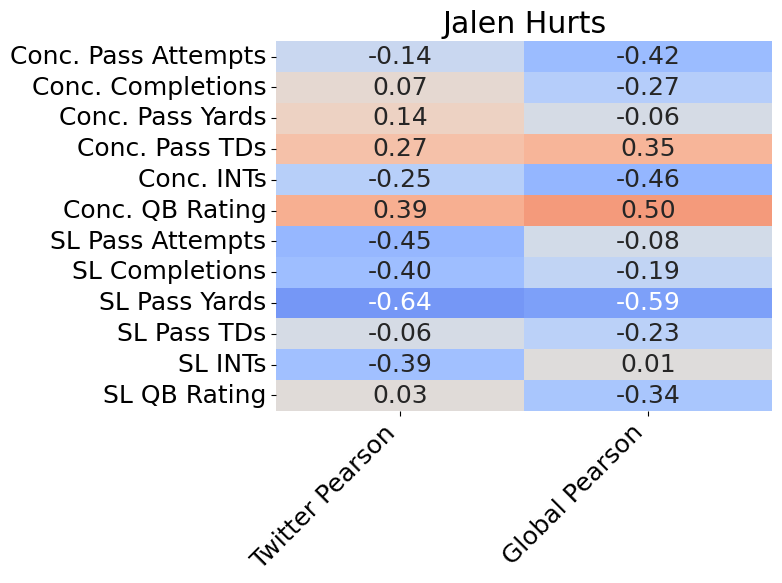

In [128]:
sns.heatmap(hurts_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f', cbar=False)
plt.xticks(rotation=45, horizontalalignment='right')
plt.ylabel('')
plt.title('Jalen Hurts')
plt.show()

In [129]:
hurts_global_lag_std.to_csv('../data/hurts_global_sent_lag.csv')
hurts_perf_lag_std.to_csv('../data/hurts_perf_lag.csv')
hurts_corr_lag.to_csv('../data/hurts_corr_lag.csv')

# Josh Allen

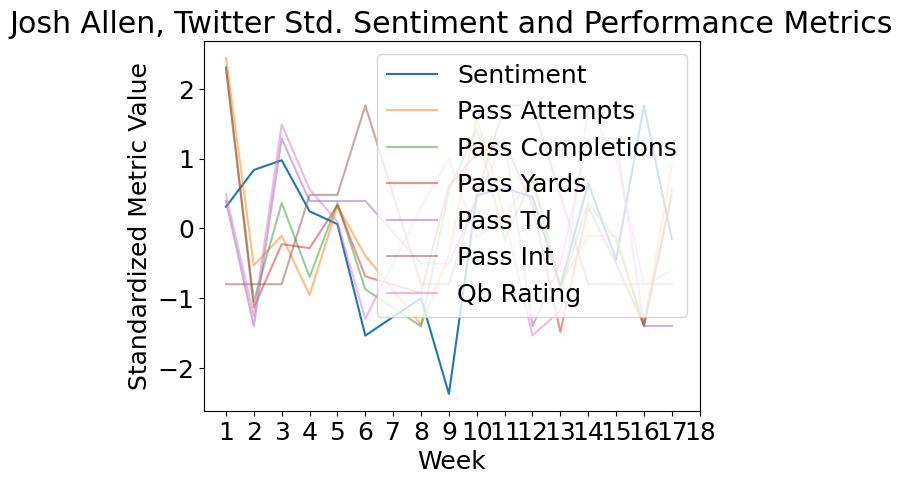

In [130]:
allen_twitter_df, allen_global_df, allen_perf_df = get_dfs_for_player('Josh Allen', qb_cols)
allen_twitter_df = allen_twitter_df[allen_twitter_df['game_id'] != 18]   # Allen also did not play W18
allen_global_df = allen_global_df[allen_global_df['game_id'] != 18]   # Allen also did not play W18
allen_global_df = allen_global_df[allen_global_df['game_id'] != 7]   # Bills bye in W7
allen_twitter_df_std, allen_global_df_std, allen_perf_df_std = standardize_cols(allen_twitter_df, allen_global_df, allen_perf_df, qb_cols)
make_plot(allen_twitter_df_std, allen_perf_df_std, 'Josh Allen, Twitter')

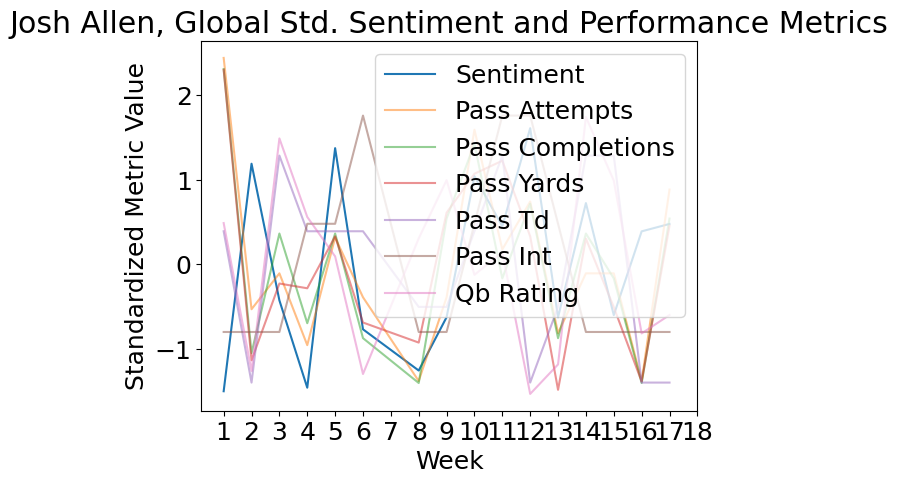

In [131]:
make_plot(allen_global_df_std, allen_perf_df_std, 'Josh Allen, Global')

In [132]:
allen_twitter_corr_df = get_corr_df(allen_twitter_df, allen_perf_df, qb_cols.copy(), qb_stats_list, 'Twitter')
allen_global_corr_df = get_corr_df(allen_global_df, allen_perf_df, qb_cols.copy(), qb_stats_list, 'Global')
allen_corr_df = pd.merge(allen_twitter_corr_df, allen_global_corr_df, on='Statistic')
allen_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,0.1364,0.1123,0.4661,0.1988,0.3811,0.4764
1,Completions,0.0560,0.0104,0.4045,0.1209,0.2411,0.3808
2,Pass Yards,0.0332,0.0250,0.4435,0.0503,0.1545,0.4137
3,Pass TDs,0.0096,0.0897,0.4102,-0.2626,-0.1840,0.4030
4,INTs,-0.0857,-0.1346,0.2621,0.2338,0.1690,0.2562
5,QB Rating,-0.0201,0.0294,0.3101,-0.3317,-0.3118,0.4500


## Lagged Performance

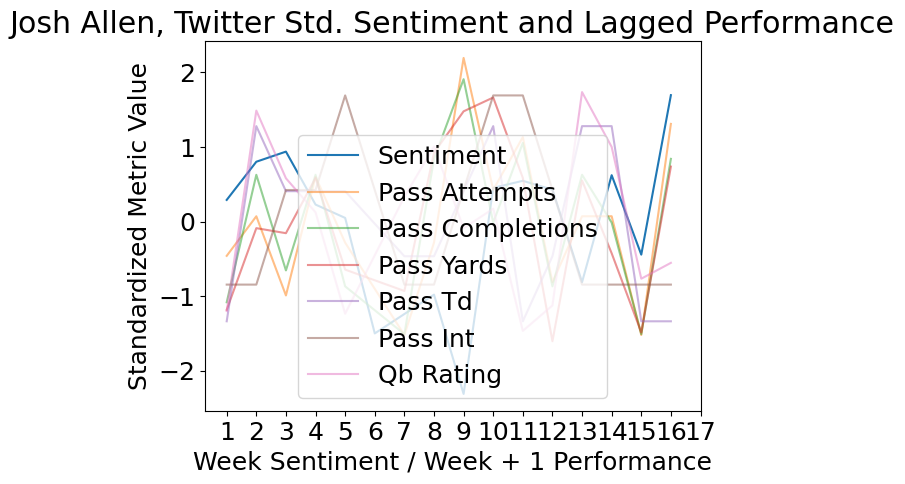

In [133]:
# Remove last row of sentiment and first row of performance
allen_twitter_lag = allen_twitter_df.iloc[:-1]
allen_global_lag = allen_global_df.iloc[:-1]
allen_perf_lag = allen_perf_df.iloc[1:]
allen_twitter_lag_std, allen_global_lag_std, allen_perf_lag_std = standardize_cols(allen_twitter_lag, allen_global_lag, allen_perf_lag, qb_cols)
make_lagged_plot(allen_twitter_lag_std, allen_perf_lag_std, 'Josh Allen, Twitter')

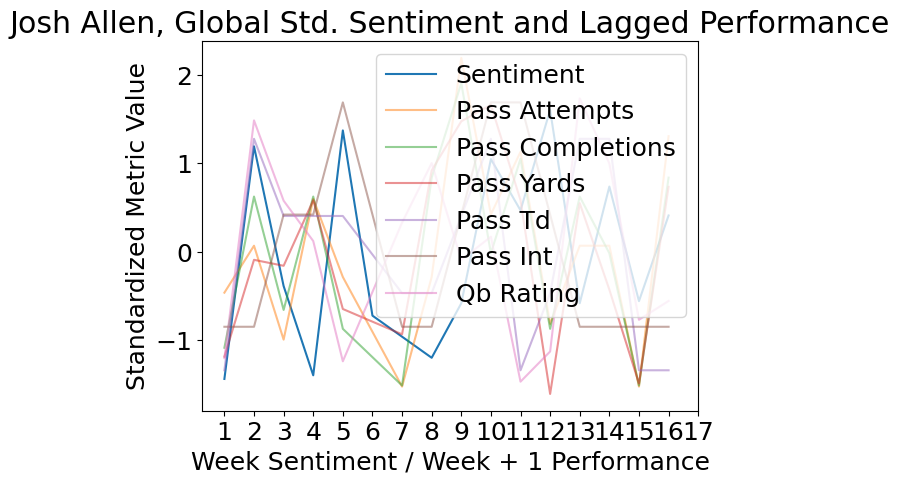

In [134]:
make_lagged_plot(allen_global_lag_std, allen_perf_lag_std, 'Josh Allen, Global')

In [135]:
allen_twitter_corr_lag = get_corr_df(allen_twitter_lag, allen_perf_lag, qb_cols.copy(), qb_stats_list, 'Twitter')
allen_global_corr_lag = get_corr_df(allen_global_lag, allen_perf_lag, qb_cols.copy(), qb_stats_list, 'Global')
allen_corr_lag = pd.merge(allen_twitter_corr_lag, allen_global_corr_lag, on='Statistic')
allen_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,-0.0034,0.1795,0.4659,0.0753,0.0682,0.3774
1,Completions,-0.1014,0.0899,0.4223,-0.0426,-0.0342,0.3305
2,Pass Yards,-0.1200,0.0107,0.3667,-0.0930,-0.1215,0.2942
3,Pass TDs,-0.0616,0.0516,0.2999,0.2864,0.2874,0.3623
4,INTs,0.1161,0.0885,0.3509,0.4254,0.4247,0.4376
5,QB Rating,-0.1673,-0.0357,0.3865,-0.1577,-0.1714,0.3081


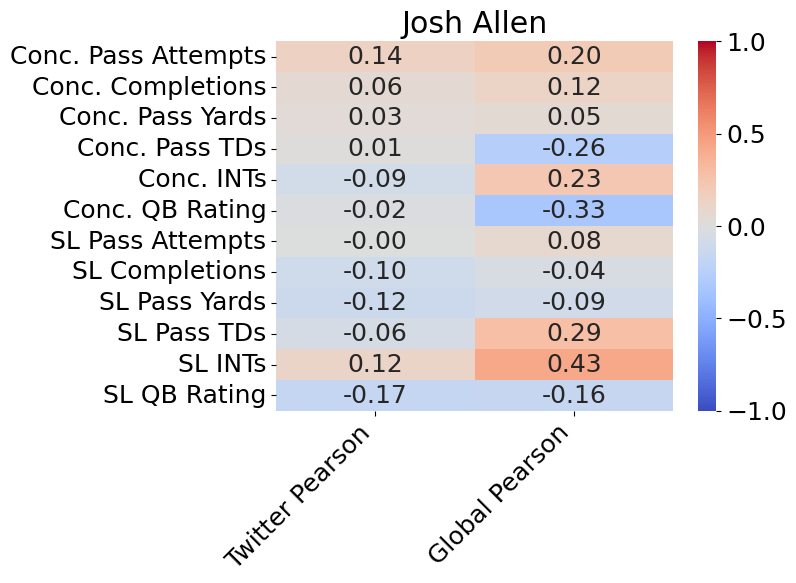

In [136]:
allen_corr_df['Statistic'] = allen_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
allen_corr_df = allen_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

allen_corr_lag['Statistic'] = allen_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
allen_corr_lag = allen_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

allen_corr_df = pd.concat([allen_corr_df, allen_corr_lag], ignore_index=True)

sns.heatmap(allen_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Josh Allen')
plt.ylabel('')
plt.show()

In [137]:
allen_global_lag_std.to_csv('../data/allen_global_sent_lag.csv')
allen_perf_lag_std.to_csv('../data/allen_perf_lag.csv')
allen_corr_lag.to_csv('../data/allen_corr_lag.csv')

# Baker Mayfield

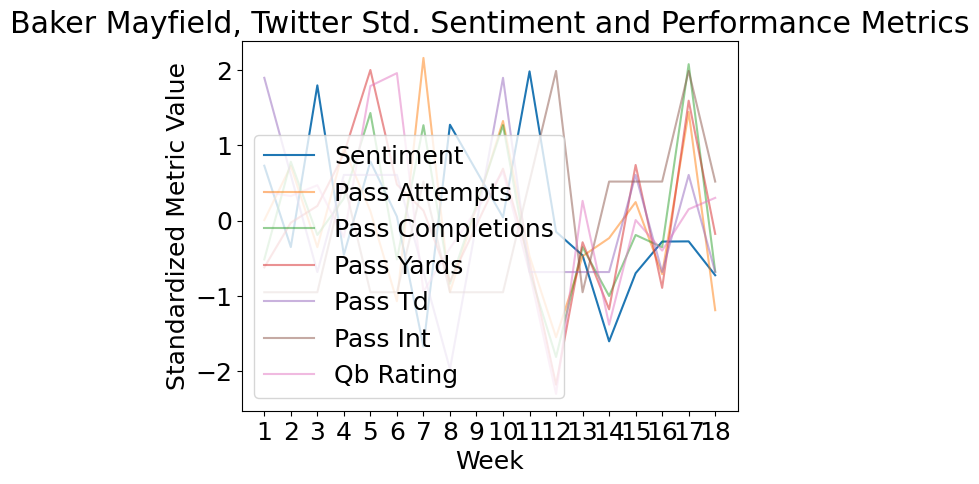

In [138]:
mayfield_twitter_df, mayfield_global_df, mayfield_perf_df = get_dfs_for_player('Baker Mayfield', qb_cols)
mayfield_global_df = mayfield_global_df[mayfield_global_df['game_id'] != 9]     # Buccaneers bye in Week 9
mayfield_twitter_df_std, mayfield_global_df_std, mayfield_perf_df_std = standardize_cols(mayfield_twitter_df, mayfield_global_df, mayfield_perf_df, qb_cols)
make_plot(mayfield_twitter_df_std, mayfield_perf_df_std, 'Baker Mayfield, Twitter')

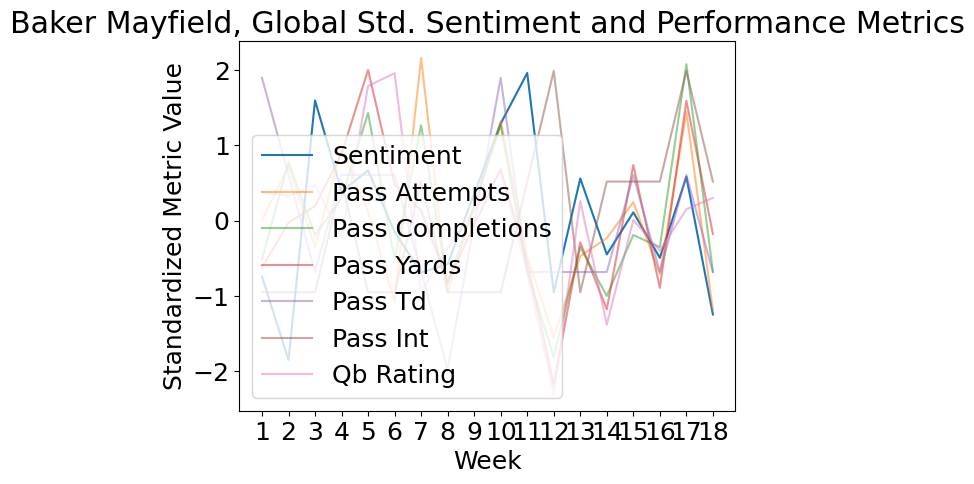

In [139]:
make_plot(mayfield_global_df_std, mayfield_perf_df_std, 'Baker Mayfield, Global')

In [140]:
mayfield_twitter_corr_df = get_corr_df(mayfield_twitter_df, mayfield_perf_df, qb_cols.copy(), qb_stats_list, 'Twitter')
mayfield_global_corr_df = get_corr_df(mayfield_global_df, mayfield_perf_df, qb_cols.copy(), qb_stats_list, 'Global')
mayfield_corr_df = pd.merge(mayfield_twitter_corr_df, mayfield_global_corr_df, on='Statistic')
mayfield_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,-0.3328,-0.2526,0.4125,0.1505,0.2538,0.3991
1,Completions,-0.1362,-0.0762,0.2893,0.2276,0.3553,0.4121
2,Pass Yards,0.0330,0.0270,0.3192,0.3955,0.4853,0.5814
3,Pass TDs,-0.0505,0.0663,0.4008,0.1075,0.1393,0.3242
4,INTs,-0.3706,-0.4123,0.5096,-0.1007,-0.1253,0.2331
5,QB Rating,0.2742,0.3578,0.4548,0.2289,0.2500,0.4247


## Lagged Performance

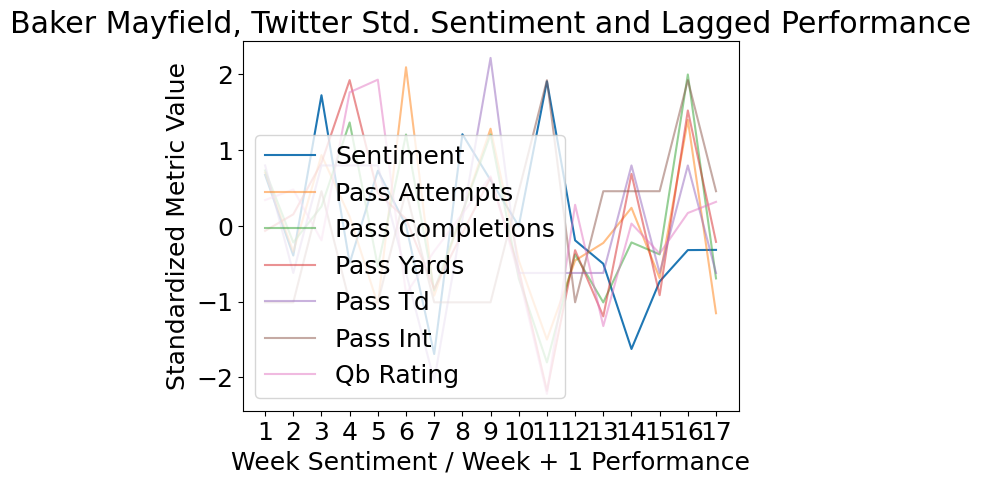

In [141]:
# Remove last row of sentiment and first row of performance
mayfield_twitter_lag = mayfield_twitter_df.iloc[:-1]
mayfield_global_lag = mayfield_global_df.iloc[:-1]
mayfield_perf_lag = mayfield_perf_df.iloc[1:]
mayfield_twitter_lag_std, mayfield_global_lag_std, mayfield_perf_lag_std = standardize_cols(mayfield_twitter_lag, mayfield_global_lag, mayfield_perf_lag, qb_cols)
make_lagged_plot(mayfield_twitter_lag_std, mayfield_perf_lag_std, 'Baker Mayfield, Twitter')

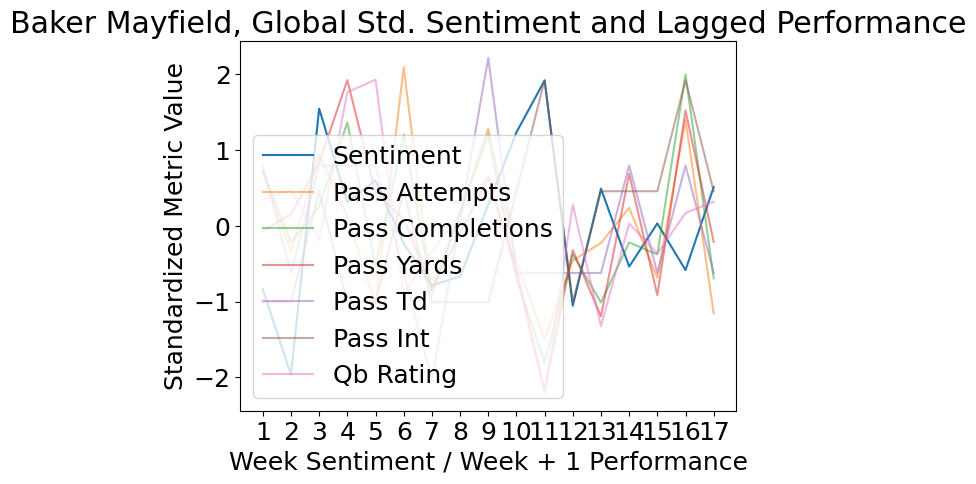

In [142]:
make_lagged_plot(mayfield_global_lag_std, mayfield_perf_lag_std, 'Baker Mayfield, Global')

In [143]:
mayfield_twitter_corr_lag = get_corr_df(mayfield_twitter_lag, mayfield_perf_lag, qb_cols.copy(), qb_stats_list, 'Twitter')
mayfield_global_corr_lag = get_corr_df(mayfield_global_lag, mayfield_perf_lag, qb_cols.copy(), qb_stats_list, 'Global')
mayfield_corr_lag = pd.merge(mayfield_twitter_corr_lag, mayfield_global_corr_lag, on='Statistic')
mayfield_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Pass Attempts,0.1189,0.0868,0.3976,-0.2695,-0.3208,0.4266
1,Completions,0.0139,0.0870,0.3636,-0.3708,-0.3835,0.4686
2,Pass Yards,-0.0927,0.0824,0.3918,-0.2769,-0.1441,0.4085
3,Pass TDs,0.4266,0.3643,0.4561,-0.0039,0.0146,0.2725
4,INTs,0.1596,0.0757,0.2826,0.5252,0.5572,0.5387
5,QB Rating,-0.1225,0.0735,0.3952,-0.3593,-0.3676,0.5436


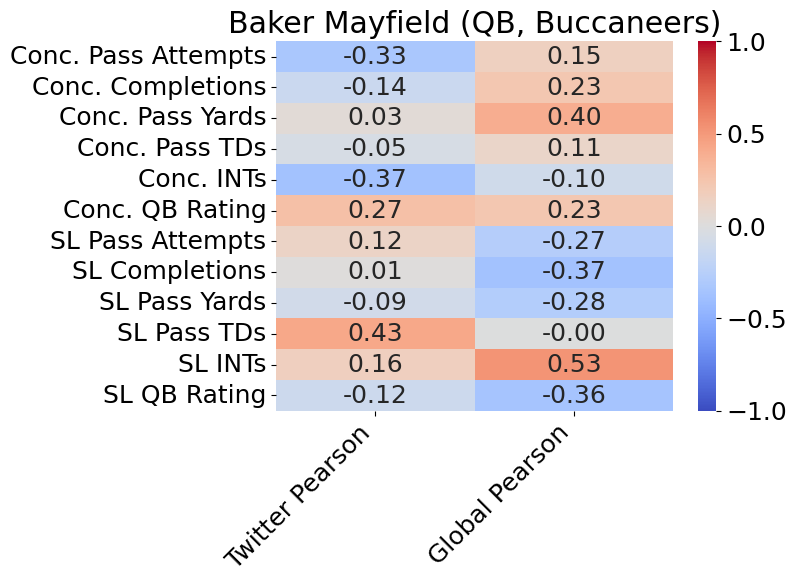

In [144]:
mayfield_corr_df['Statistic'] = mayfield_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
mayfield_corr_df = mayfield_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

mayfield_corr_lag['Statistic'] = mayfield_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
mayfield_corr_lag = mayfield_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

mayfield_corr_df = pd.concat([mayfield_corr_df, mayfield_corr_lag], ignore_index=True)

sns.heatmap(mayfield_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Baker Mayfield (QB, Buccaneers)')
plt.ylabel('')
plt.show()

# AJ Brown

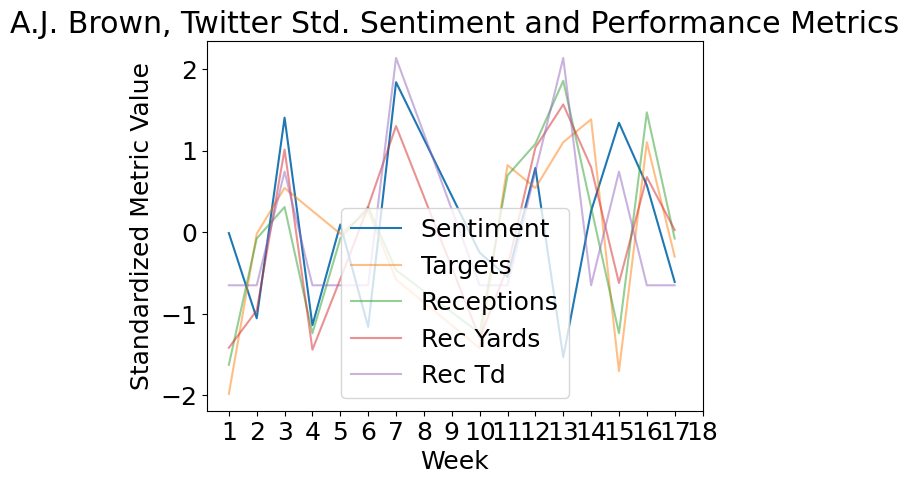

In [145]:
brown_twitter_df, brown_global_df, brown_perf_df = get_dfs_for_player('A.J. Brown', wr_cols)
brown_twitter_df = brown_twitter_df[~brown_twitter_df['game_id'].isin([8, 18])]   # Eagles rested starters in W18, Brown injured W8
brown_global_df = brown_global_df[~brown_global_df['game_id'].isin([8, 9, 18])]   # Eagles rested starters in W18, Brown injured W8, bye W9
brown_twitter_df_std, brown_global_df_std, brown_perf_df_std = standardize_cols(brown_twitter_df, brown_global_df, brown_perf_df, wr_cols)
make_plot(brown_twitter_df_std, brown_perf_df_std, 'A.J. Brown, Twitter')

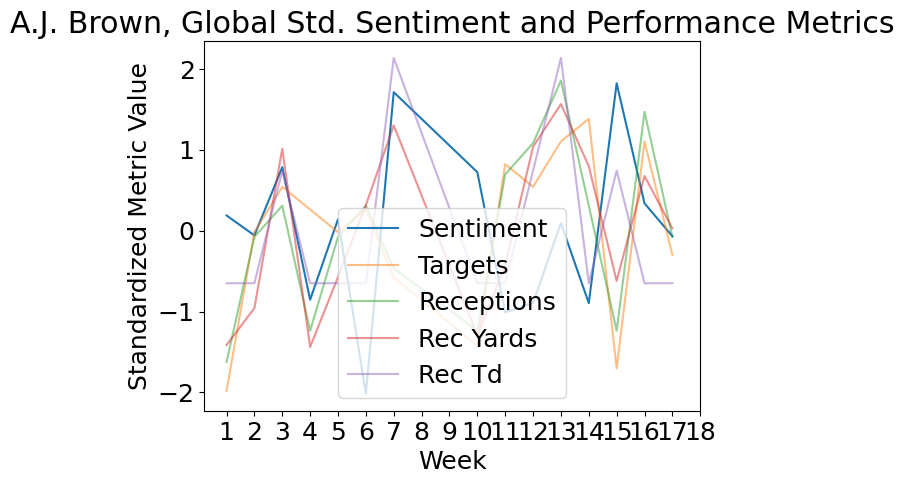

In [146]:
make_plot(brown_global_df_std, brown_perf_df_std, 'A.J. Brown, Global')

In [147]:
brown_twitter_corr_df = get_corr_df(brown_twitter_df, brown_perf_df, wr_cols.copy(), wr_stats_list, 'Twitter')
brown_global_corr_df = get_corr_df(brown_global_df, brown_perf_df, wr_cols.copy(), wr_stats_list, 'Global')
brown_corr_df = pd.merge(brown_twitter_corr_df, brown_global_corr_df, on='Statistic')
brown_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,-0.2220,-0.1290,0.3744,-0.5250,-0.4982,0.5895
1,Receptions,-0.1351,-0.0903,0.2986,-0.3235,-0.3971,0.4441
2,Rec Yards,0.3185,0.3000,0.4846,0.0279,-0.0143,0.2602
3,Rec TDs,0.3849,0.4173,0.6184,0.4940,0.4536,0.4994


## Lagged Performance

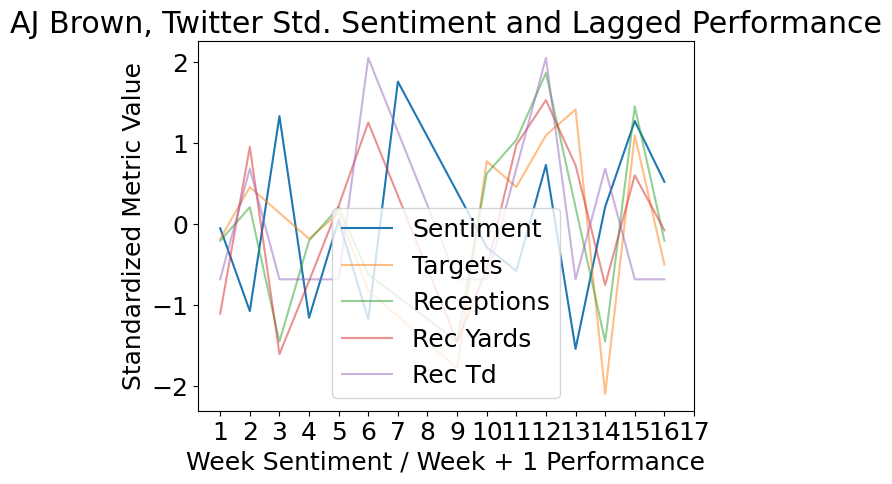

In [148]:
# Remove last row of sentiment and first row of performance
brown_twitter_lag = brown_twitter_df.iloc[:-1]
brown_global_lag = brown_global_df.iloc[:-1]
brown_perf_lag = brown_perf_df.iloc[1:]
brown_twitter_lag_std, brown_global_lag_std, brown_perf_lag_std = standardize_cols(brown_twitter_lag, brown_global_lag, brown_perf_lag, wr_cols)
make_lagged_plot(brown_twitter_lag_std, brown_perf_lag_std, 'AJ Brown, Twitter')

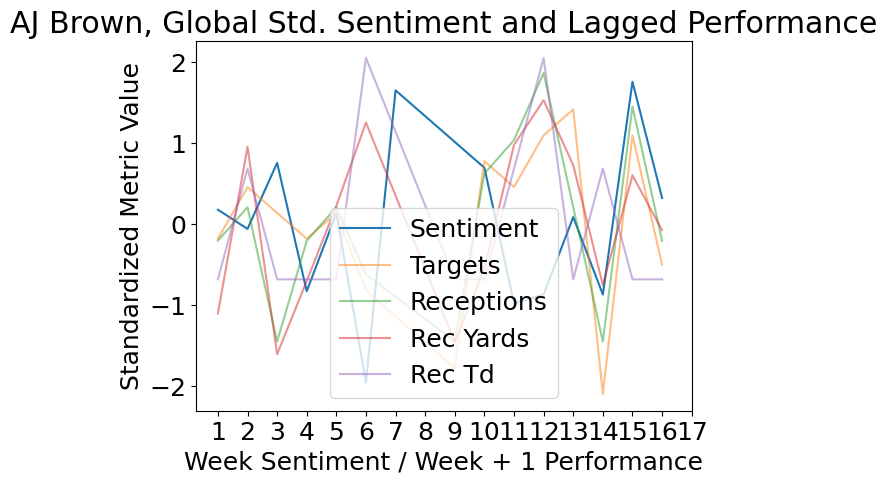

In [149]:
make_lagged_plot(brown_global_lag_std, brown_perf_lag_std, 'AJ Brown, Global')

In [150]:
brown_twitter_corr_lag = get_corr_df(brown_twitter_lag, brown_perf_lag, wr_cols.copy(), wr_stats_list, 'Twitter')
brown_global_corr_lag = get_corr_df(brown_global_lag, brown_perf_lag, wr_cols.copy(), wr_stats_list, 'Global')
brown_corr_lag = pd.merge(brown_twitter_corr_lag, brown_global_corr_lag, on='Statistic')
brown_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,-0.2444,-0.1722,0.3672,0.1236,0.1391,0.3412
1,Receptions,-0.1444,-0.1537,0.4977,-0.0404,-0.0512,0.3637
2,Rec Yards,-0.4400,-0.4505,0.4923,-0.4731,-0.5736,0.5016
3,Rec TDs,-0.2284,-0.2271,0.3185,-0.7379,-0.7949,0.7390


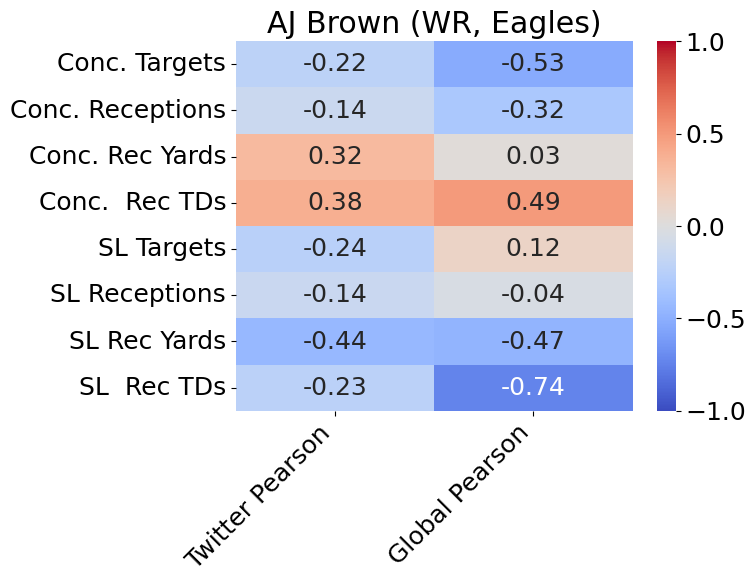

In [151]:
brown_corr_df['Statistic'] = brown_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
brown_corr_df = brown_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

brown_corr_lag['Statistic'] = brown_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
brown_corr_lag = brown_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

brown_corr_df = pd.concat([brown_corr_df, brown_corr_lag], ignore_index=True)

sns.heatmap(brown_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('AJ Brown (WR, Eagles)')
plt.ylabel('')
plt.show()

# Ja'Marr Chase

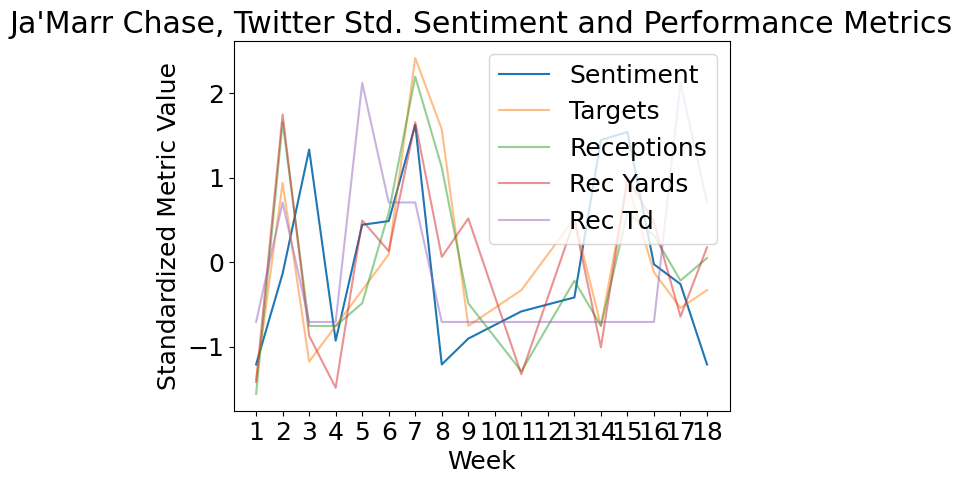

In [191]:
chase_twitter_df, chase_global_df, chase_perf_df = get_dfs_for_player('Ja\'Marr Chase', wr_cols)
chase_twitter_df = chase_twitter_df[chase_twitter_df['game_id'] != 12]   # Chase injured in W12
chase_global_df = chase_global_df[chase_global_df['game_id'] != 12]   # Chase injured in W12
chase_global_df = chase_global_df[chase_global_df['game_id'] != 10]   # Bengals bye in W12
chase_twitter_df_std, chase_global_df_std, chase_perf_df_std = standardize_cols(chase_twitter_df, chase_global_df, chase_perf_df, wr_cols)
make_plot(chase_twitter_df_std, chase_perf_df_std, 'Ja\'Marr Chase, Twitter')

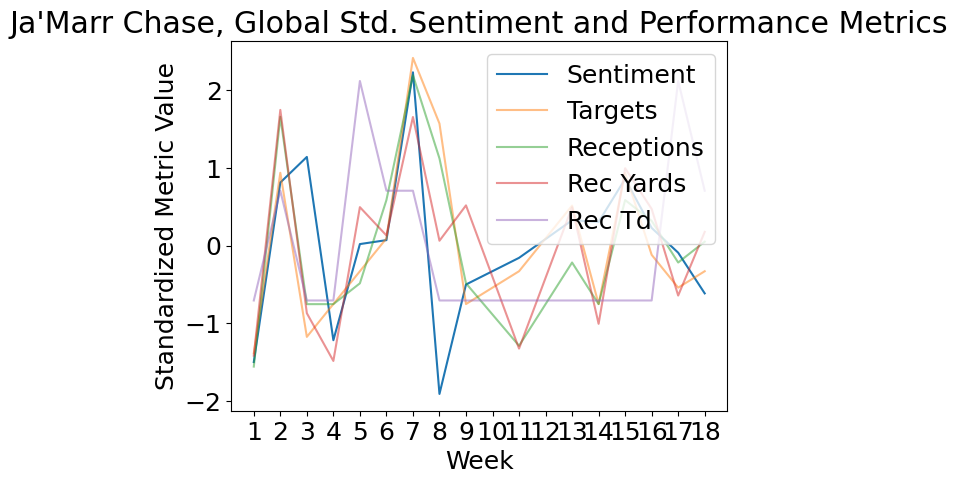

In [153]:
make_plot(chase_global_df_std, chase_perf_df_std, 'Ja\'Marr Chase, Global')

In [192]:
chase_twitter_corr_df = get_corr_df(chase_twitter_df, chase_perf_df, wr_cols.copy(), wr_stats_list, 'Twitter')
chase_global_corr_df = get_corr_df(chase_global_df, chase_perf_df, wr_cols.copy(), wr_stats_list, 'Global')
chase_corr_df = pd.merge(chase_twitter_corr_df, chase_global_corr_df, on='Statistic')
chase_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,0.2607,0.2673,0.3501,0.3883,0.3449,0.5641
1,Receptions,0.2953,0.2965,0.3558,0.4529,0.3622,0.5239
2,Rec Yards,0.2950,0.3926,0.3793,0.5427,0.5416,0.5651
3,Rec TDs,0.1005,0.1885,0.2848,0.2083,0.1230,0.3480


## Lagged Performance

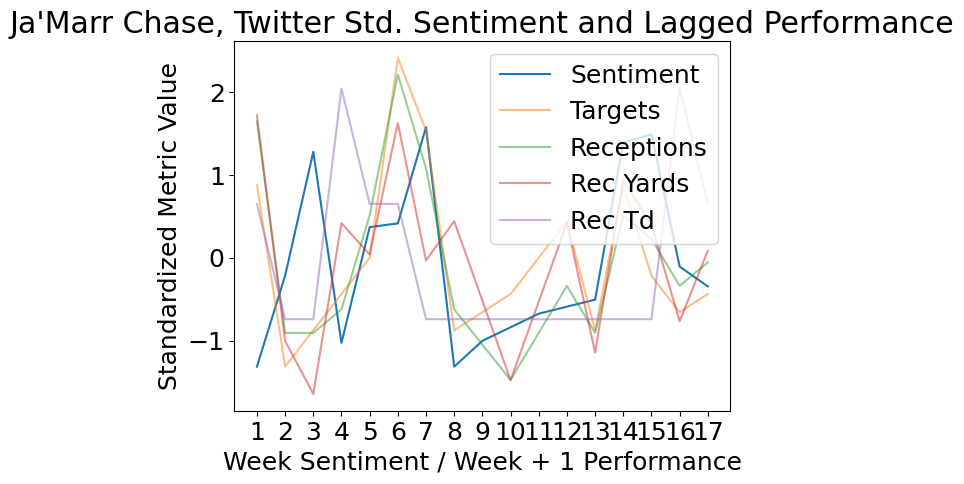

In [193]:
# Remove last row of sentiment and first row of performance
chase_twitter_lag = chase_twitter_df.iloc[:-1]
chase_global_lag = chase_global_df.iloc[:-1]
chase_perf_lag = chase_perf_df.iloc[1:]
chase_twitter_lag_std, chase_global_lag_std, chase_perf_lag_std = standardize_cols(chase_twitter_lag, chase_global_lag, chase_perf_lag, wr_cols)
make_lagged_plot(chase_twitter_lag_std, chase_perf_lag_std, 'Ja\'Marr Chase, Twitter')

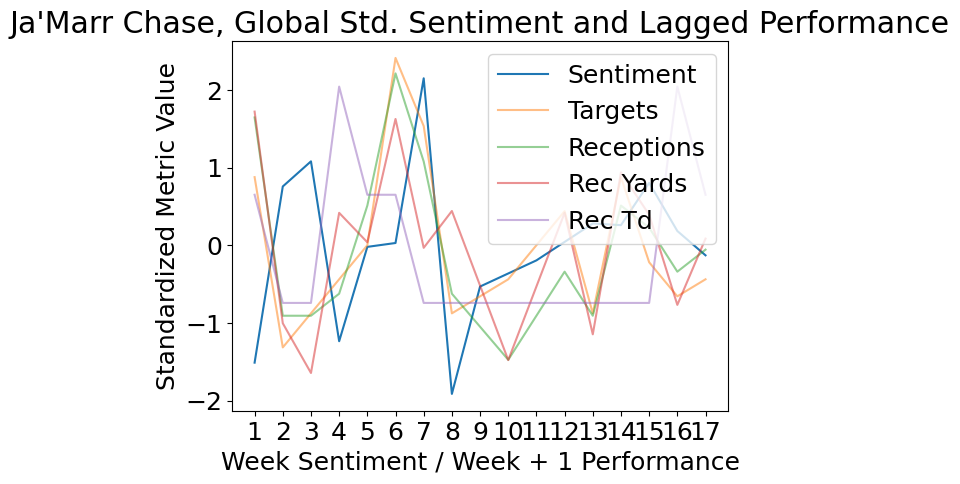

In [156]:
make_lagged_plot(chase_global_lag_std, chase_perf_lag_std, 'Ja\'Marr Chase, Global')

In [194]:
chase_twitter_corr_lag = get_corr_df(chase_twitter_lag, chase_perf_lag, wr_cols.copy(), wr_stats_list, 'Twitter')
chase_global_corr_lag = get_corr_df(chase_global_lag, chase_perf_lag, wr_cols.copy(), wr_stats_list, 'Global')
chase_corr_lag = pd.merge(chase_twitter_corr_lag, chase_global_corr_lag, on='Statistic')
chase_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,0.3160,0.3126,0.4096,0.1473,-0.0432,0.3513
1,Receptions,0.2944,0.3606,0.4814,0.0691,0.0162,0.3614
2,Rec Yards,-0.0527,-0.1986,0.2952,-0.3822,-0.5004,0.4584
3,Rec TDs,-0.2925,-0.2216,0.3685,-0.3472,-0.3938,0.4371


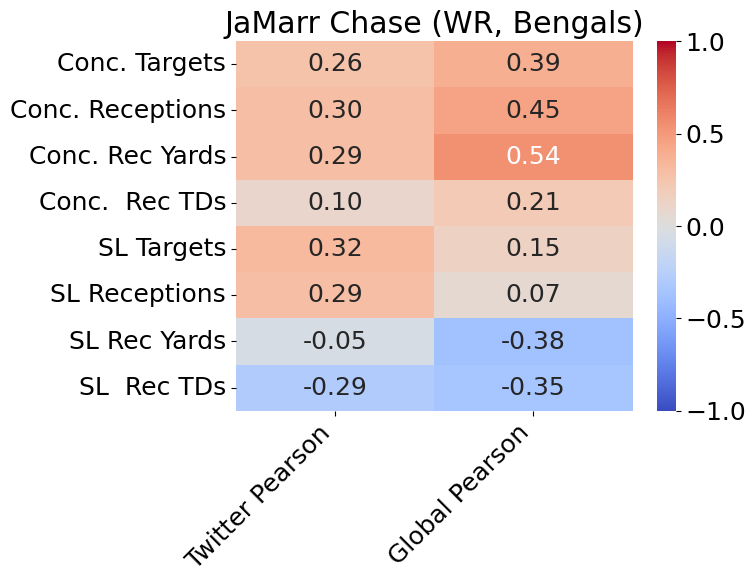

In [195]:
chase_corr_df['Statistic'] = chase_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
chase_corr_df = chase_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

chase_corr_lag['Statistic'] = chase_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
chase_corr_lag = chase_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

chase_corr_df = pd.concat([chase_corr_df, chase_corr_lag], ignore_index=True)

sns.heatmap(chase_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('JaMarr Chase (WR, Bengals)')
plt.ylabel('')
plt.show()

# George Pickens

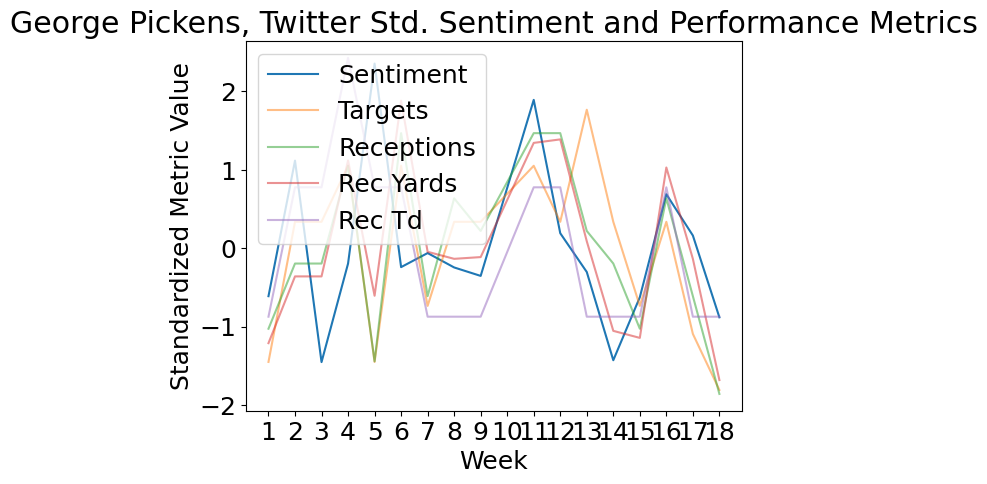

In [159]:
pickens_twitter_df, pickens_global_df, pickens_perf_df = get_dfs_for_player('George Pickens', wr_cols)
pickens_global_df = pickens_global_df[pickens_global_df['game_id'] != 10]   # Cowboys bye in W10
pickens_twitter_df_std, pickens_global_df_std, pickens_perf_df_std = standardize_cols(pickens_twitter_df, pickens_global_df, pickens_perf_df, wr_cols)
make_plot(pickens_twitter_df_std, pickens_perf_df_std, 'George Pickens, Twitter')

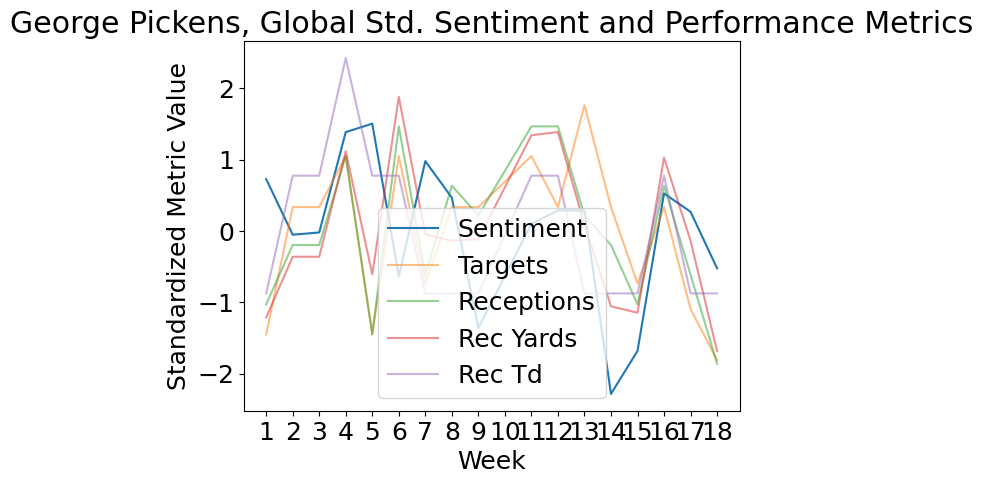

In [160]:
make_plot(pickens_global_df_std, pickens_perf_df_std, 'George Pickens, Global')

In [161]:
pickens_twitter_corr_df = get_corr_df(pickens_twitter_df, pickens_perf_df, wr_cols.copy(), wr_stats_list, 'Twitter')
pickens_global_corr_df = get_corr_df(pickens_global_df, pickens_perf_df, wr_cols.copy(), wr_stats_list, 'Global')
pickens_corr_df = pd.merge(pickens_twitter_corr_df, pickens_global_corr_df, on='Statistic')
pickens_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,-0.0065,0.1160,0.3047,-0.0876,-0.1147,0.3012
1,Receptions,0.1431,0.3000,0.4059,0.0570,0.0074,0.3193
2,Rec Yards,0.3538,0.4982,0.5052,0.2892,0.2110,0.4227
3,Rec TDs,0.4039,0.5203,0.5581,0.4367,0.2989,0.4209


## Lagged Performance

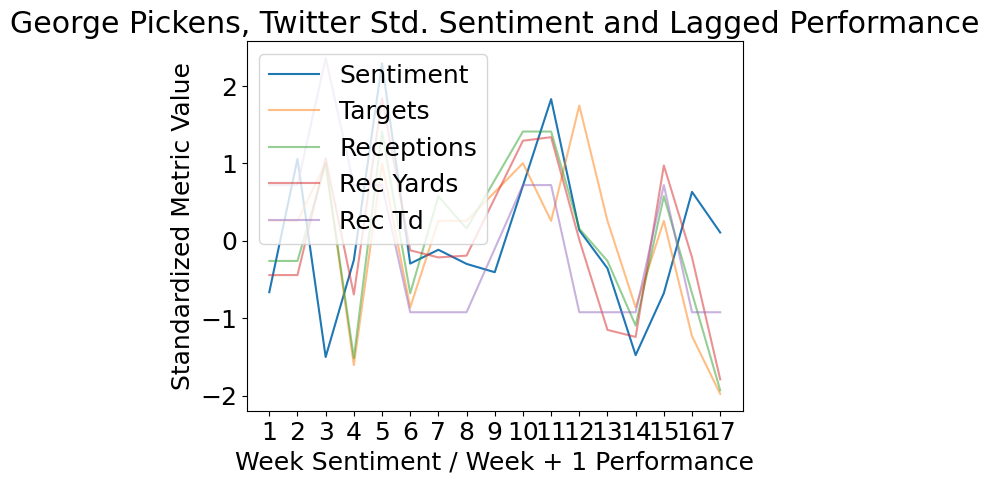

In [162]:
# Remove last row of sentiment and first row of performance
pickens_twitter_lag = pickens_twitter_df.iloc[:-1]
pickens_global_lag = pickens_global_df.iloc[:-1]
pickens_perf_lag = pickens_perf_df.iloc[1:]
pickens_twitter_lag_std, pickens_global_lag_std, pickens_perf_lag_std = standardize_cols(pickens_twitter_lag, pickens_global_lag, pickens_perf_lag, wr_cols)
make_lagged_plot(pickens_twitter_lag_std, pickens_perf_lag_std, 'George Pickens, Twitter')

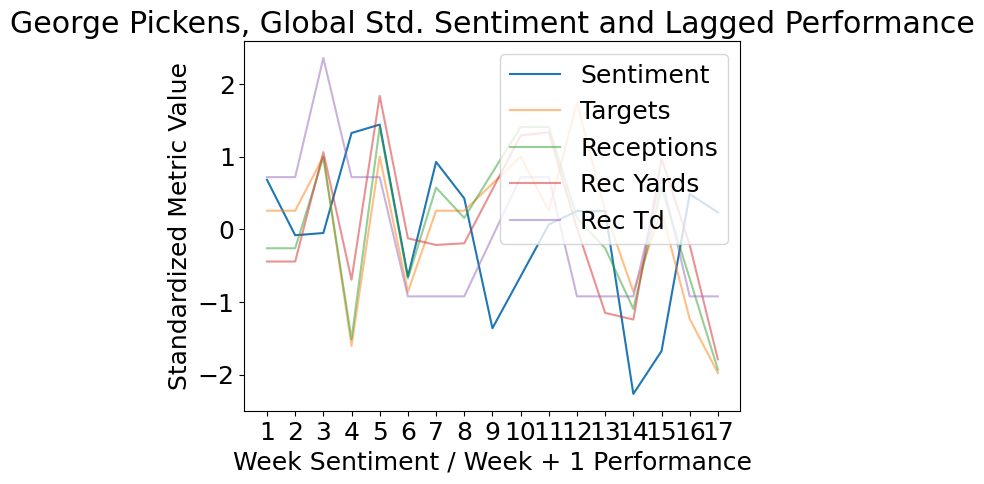

In [163]:
make_lagged_plot(pickens_global_lag_std, pickens_perf_lag_std, 'George Pickens, Global')

In [164]:
pickens_twitter_corr_lag = get_corr_df(pickens_twitter_lag, pickens_perf_lag, wr_cols.copy(), wr_stats_list, 'Twitter')
pickens_global_corr_lag = get_corr_df(pickens_global_lag, pickens_perf_lag, wr_cols.copy(), wr_stats_list, 'Global')
pickens_corr_lag = pd.merge(pickens_twitter_corr_lag, pickens_global_corr_lag, on='Statistic')
pickens_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Targets,0.1097,-0.0370,0.2958,-0.0035,-0.0015,0.2748
1,Receptions,0.3009,0.0726,0.4446,-0.0157,-0.0074,0.2900
2,Rec Yards,0.3696,0.1753,0.4866,-0.0050,-0.0324,0.3836
3,Rec TDs,0.0177,-0.1238,0.4210,0.0301,-0.0578,0.2846


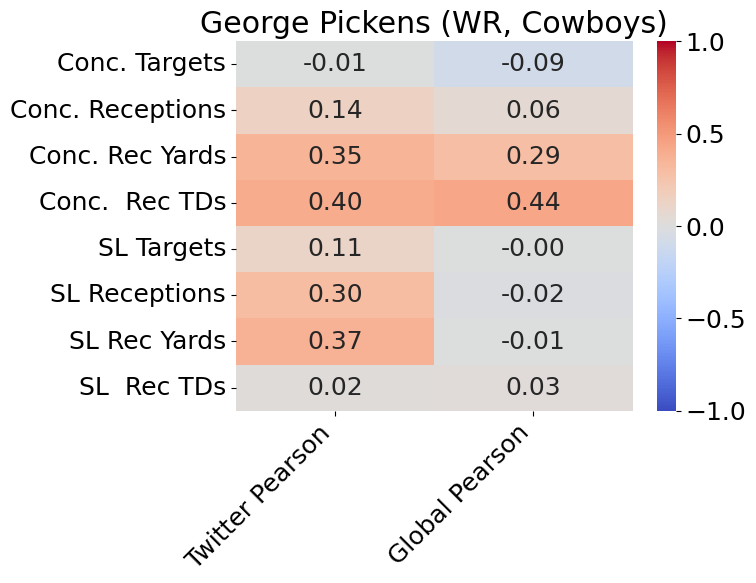

In [165]:
pickens_corr_df['Statistic'] = pickens_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
pickens_corr_df = pickens_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

pickens_corr_lag['Statistic'] = pickens_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
pickens_corr_lag = pickens_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

pickens_corr_df = pd.concat([pickens_corr_df, pickens_corr_lag], ignore_index=True)

sns.heatmap(pickens_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('George Pickens (WR, Cowboys)')
plt.ylabel('')
plt.show()

# Saquon Barkley

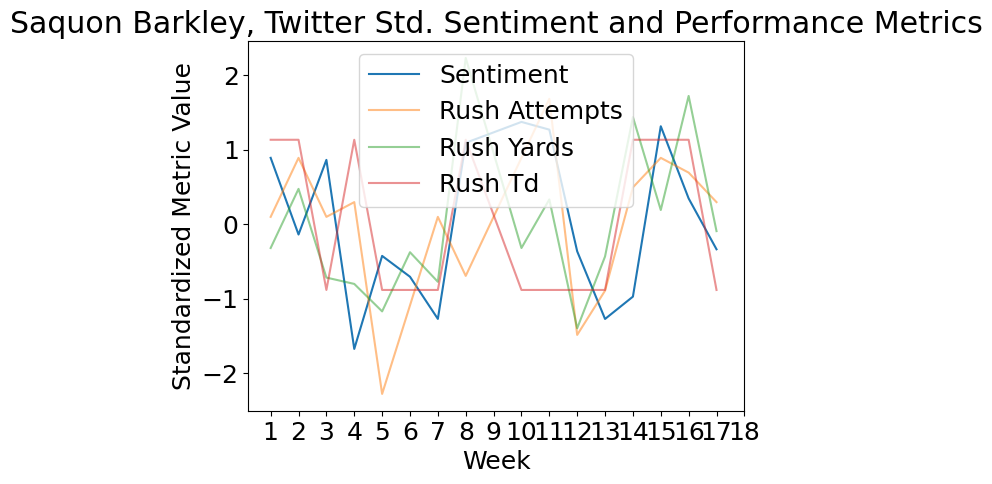

In [166]:
barkley_twitter_df, barkley_global_df, barkley_perf_df = get_dfs_for_player('Saquon Barkley', rb_cols)
barkley_twitter_df = barkley_twitter_df[~barkley_twitter_df['game_id'].isin([18])]   # Eagles rested starters in W18, Brown injured W8
barkley_global_df = barkley_global_df[~barkley_global_df['game_id'].isin([8, 18])]   # Eagles rested starters in W18, Brown injured W8, bye W9
barkley_twitter_df_std, barkley_global_df_std, barkley_perf_df_std = standardize_cols(barkley_twitter_df, barkley_global_df, barkley_perf_df, rb_cols)
make_plot(barkley_twitter_df_std, barkley_perf_df_std, 'Saquon Barkley, Twitter')

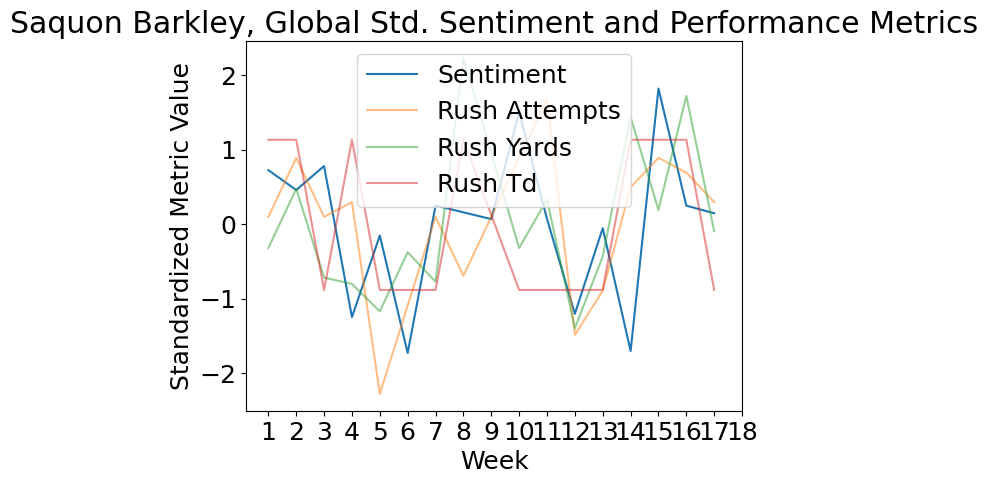

In [167]:
make_plot(barkley_global_df_std, barkley_perf_df_std, 'Saquon Barkley, Global')

In [168]:
barkley_twitter_corr_df = get_corr_df(barkley_twitter_df, barkley_perf_df, rb_cols.copy(), rb_stats_list, 'Twitter')
barkley_global_corr_df = get_corr_df(barkley_global_df, barkley_perf_df, rb_cols.copy(), rb_stats_list, 'Global')
barkley_corr_df = pd.merge(barkley_twitter_corr_df, barkley_global_corr_df, on='Statistic')
barkley_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,0.3919,0.4959,0.4826,0.4179,0.5063,0.5130
1,Rush Yards,0.3174,0.4768,0.4098,0.0482,0.2060,0.3372
2,Rush TDs,0.1087,0.1230,0.2253,0.0475,0.0957,0.1563


# Lagged Performance

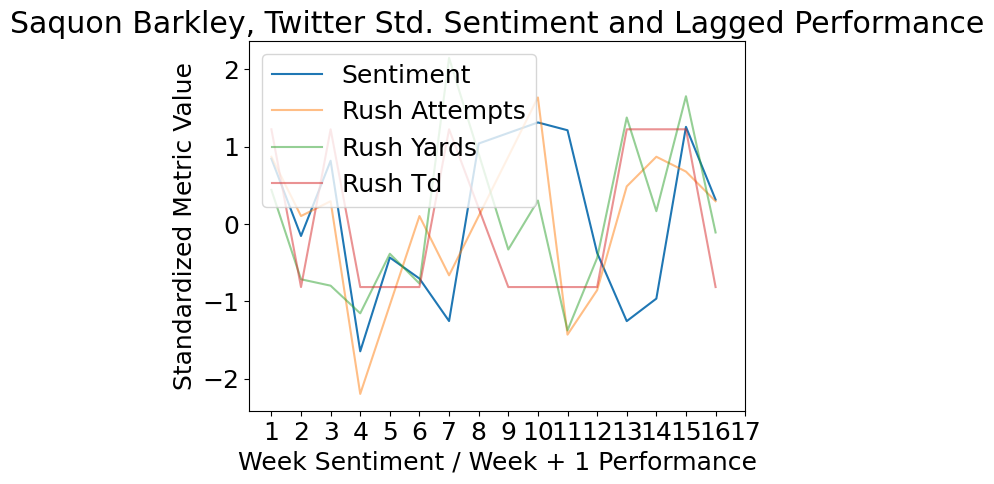

In [169]:
# Remove last row of sentiment and first row of performance
barkley_twitter_lag = barkley_twitter_df.iloc[:-1]
barkley_global_lag = barkley_global_df.iloc[:-1]
barkley_perf_lag = barkley_perf_df.iloc[1:]
barkley_twitter_lag_std, barkley_global_lag_std, barkley_perf_lag_std = standardize_cols(barkley_twitter_lag, barkley_global_lag, barkley_perf_lag, rb_cols)
make_lagged_plot(barkley_twitter_lag_std, barkley_perf_lag_std, 'Saquon Barkley, Twitter')

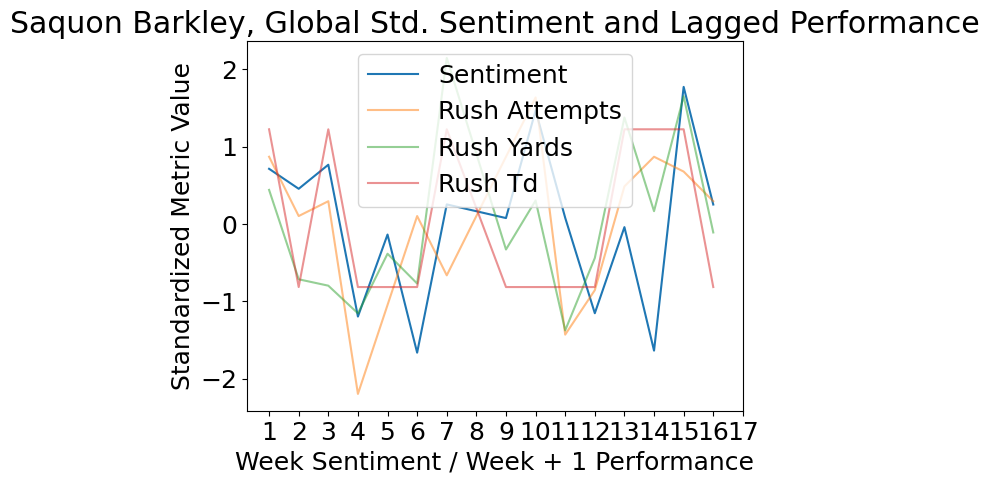

In [170]:
make_lagged_plot(barkley_global_lag_std, barkley_perf_lag_std, 'Saquon Barkley, Global')

In [171]:
barkley_twitter_corr_lag = get_corr_df(barkley_twitter_lag, barkley_perf_lag, rb_cols.copy(), rb_stats_list, 'Twitter')
barkley_global_corr_lag = get_corr_df(barkley_global_lag, barkley_perf_lag, rb_cols.copy(), rb_stats_list, 'Global')
barkley_corr_lag = pd.merge(barkley_twitter_corr_lag, barkley_global_corr_lag, on='Statistic')
barkley_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,0.4623,0.4452,0.4802,0.4340,0.4058,0.4830
1,Rush Yards,-0.1033,0.0357,0.3402,0.4026,0.3714,0.4359
2,Rush TDs,-0.0763,-0.1260,0.2515,0.2485,0.3150,0.2943


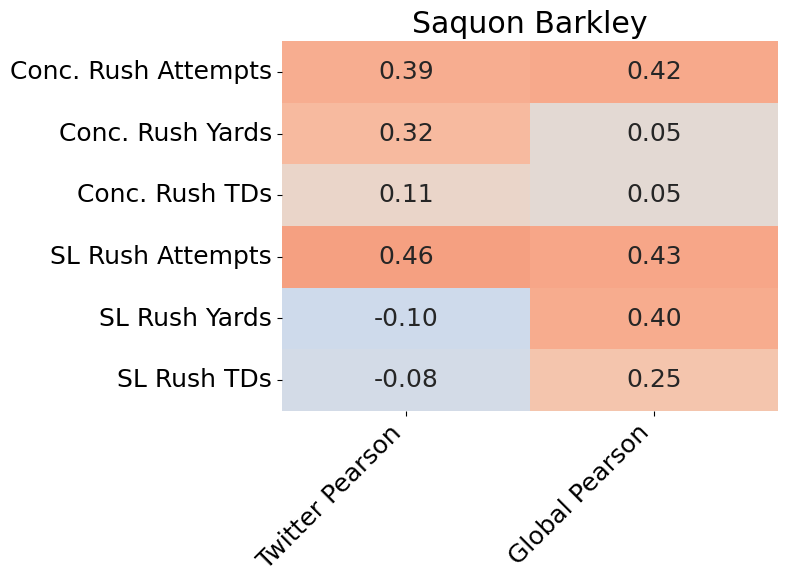

In [172]:
barkley_corr_df['Statistic'] = barkley_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
barkley_corr_df = barkley_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

barkley_corr_lag['Statistic'] = barkley_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
barkley_corr_lag = barkley_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

barkley_corr_df = pd.concat([barkley_corr_df, barkley_corr_lag], ignore_index=True)

sns.heatmap(barkley_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f', cbar=False)
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Saquon Barkley')
plt.ylabel('')
plt.show()

In [173]:
barkley_global_lag_std.to_csv('../data/barkley_global_sent_lag.csv')
barkley_perf_lag_std.to_csv('../data/barkley_perf_lag.csv')
barkley_corr_lag.to_csv('../data/barkley_corr_lag.csv')

# James Cook

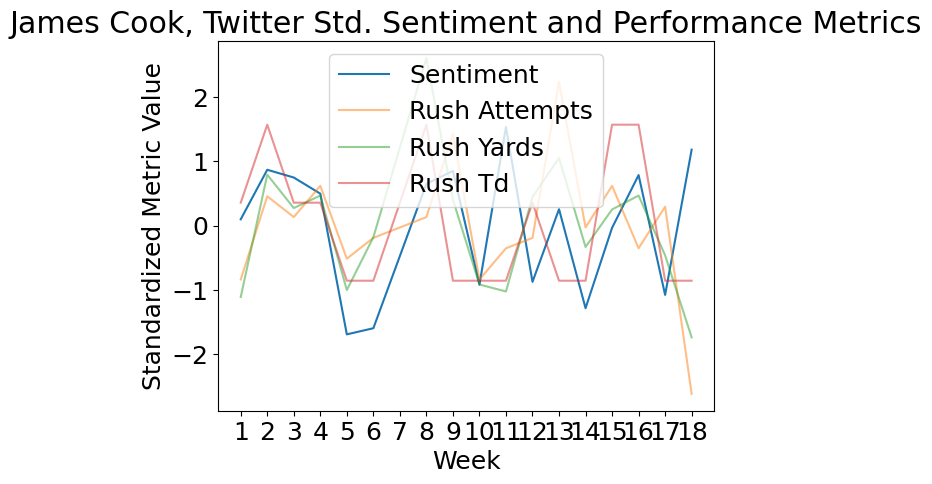

In [174]:
cook_twitter_df, cook_global_df, cook_perf_df = get_dfs_for_player('James Cook', rb_cols)
# cook_twitter_df = cook_twitter_df[~cook_twitter_df['game_id'].isin([18])] 
cook_global_df = cook_global_df[~cook_global_df['game_id'].isin([7])]   # Bills bye W7
cook_twitter_df_std, cook_global_df_std, cook_perf_df_std = standardize_cols(cook_twitter_df, cook_global_df, cook_perf_df, rb_cols)
make_plot(cook_twitter_df_std, cook_perf_df_std, 'James Cook, Twitter')

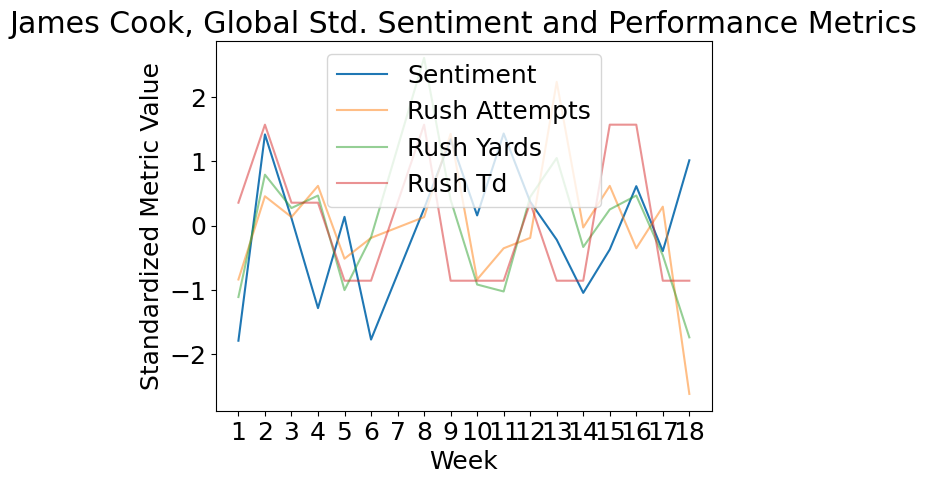

In [175]:
make_plot(cook_global_df_std, cook_perf_df_std, 'James Cook, Global')

In [176]:
cook_twitter_corr_df = get_corr_df(cook_twitter_df, cook_perf_df, rb_cols.copy(), rb_stats_list, 'Twitter')
cook_global_corr_df = get_corr_df(cook_global_df, cook_perf_df, rb_cols.copy(), rb_stats_list, 'Global')
cook_corr_df = pd.merge(cook_twitter_corr_df, cook_global_corr_df, on='Statistic')
cook_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,0.0290,0.0873,0.4078,-0.0471,-0.0897,0.3498
1,Rush Yards,0.2013,0.1754,0.4834,0.0730,0.1177,0.3197
2,Rush TDs,0.3584,0.2827,0.4643,0.0907,0.0727,0.2404


## Lagged Performance

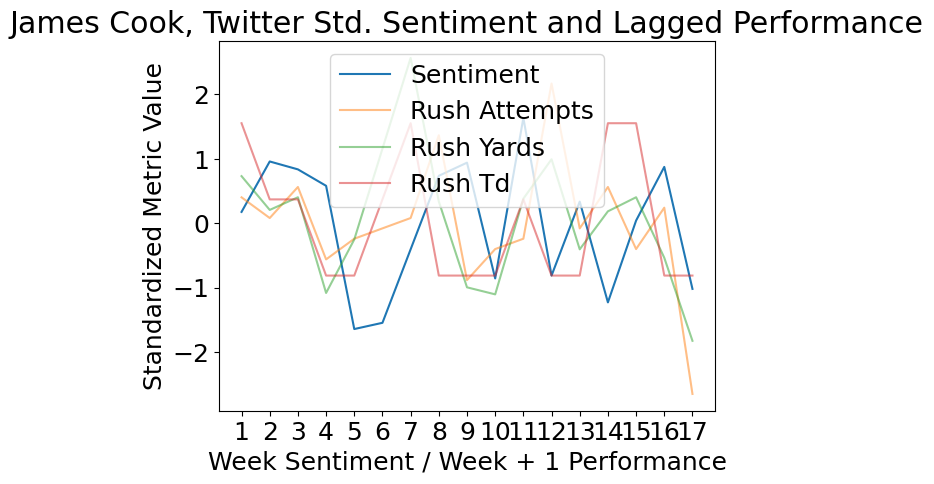

In [177]:
# Remove last row of sentiment and first row of performance
cook_twitter_lag = cook_twitter_df.iloc[:-1]
cook_global_lag = cook_global_df.iloc[:-1]
cook_perf_lag = cook_perf_df.iloc[1:]
cook_twitter_lag_std, cook_global_lag_std, cook_perf_lag_std = standardize_cols(cook_twitter_lag, cook_global_lag, cook_perf_lag, rb_cols)
make_lagged_plot(cook_twitter_lag_std, cook_perf_lag_std, 'James Cook, Twitter')

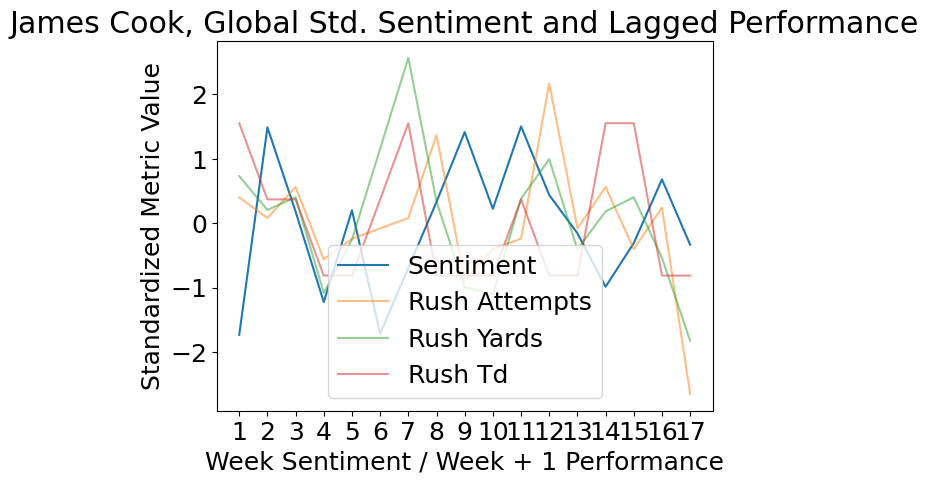

In [178]:
make_lagged_plot(cook_global_lag_std, cook_perf_lag_std, 'James Cook, Global')

In [179]:
cook_twitter_corr_lag = get_corr_df(cook_twitter_lag, cook_perf_lag, rb_cols.copy(), rb_stats_list, 'Twitter')
cook_global_corr_lag = get_corr_df(cook_global_lag, cook_perf_lag, rb_cols.copy(), rb_stats_list, 'Global')
cook_corr_lag = pd.merge(cook_twitter_corr_lag, cook_global_corr_lag, on='Statistic')
cook_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,0.0690,0.0192,0.2988,0.0222,0.0354,0.3542
1,Rush Yards,-0.1498,-0.0397,0.3747,-0.2842,-0.1236,0.3998
2,Rush TDs,-0.1250,-0.0919,0.3281,-0.4667,-0.3890,0.5755


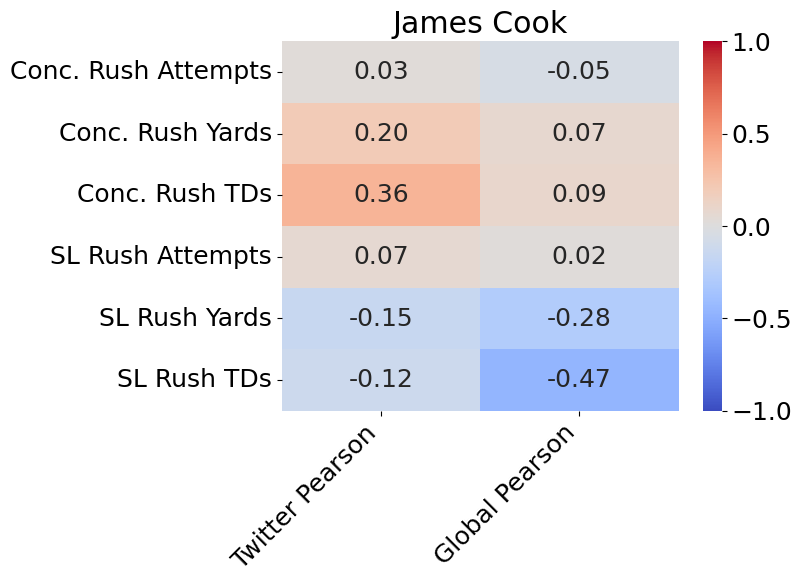

In [180]:
cook_corr_df['Statistic'] = cook_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
cook_corr_df = cook_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

cook_corr_lag['Statistic'] = cook_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
cook_corr_lag = cook_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

cook_corr_df = pd.concat([cook_corr_df, cook_corr_lag], ignore_index=True)

sns.heatmap(cook_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('James Cook')
plt.ylabel('')
plt.show()

In [181]:
cook_global_lag_std.to_csv('../data/cook_global_sent_lag.csv')
cook_perf_lag_std.to_csv('../data/cook_perf_lag.csv')
cook_corr_lag.to_csv('../data/cook_corr_lag.csv')

# Jonathan Taylor

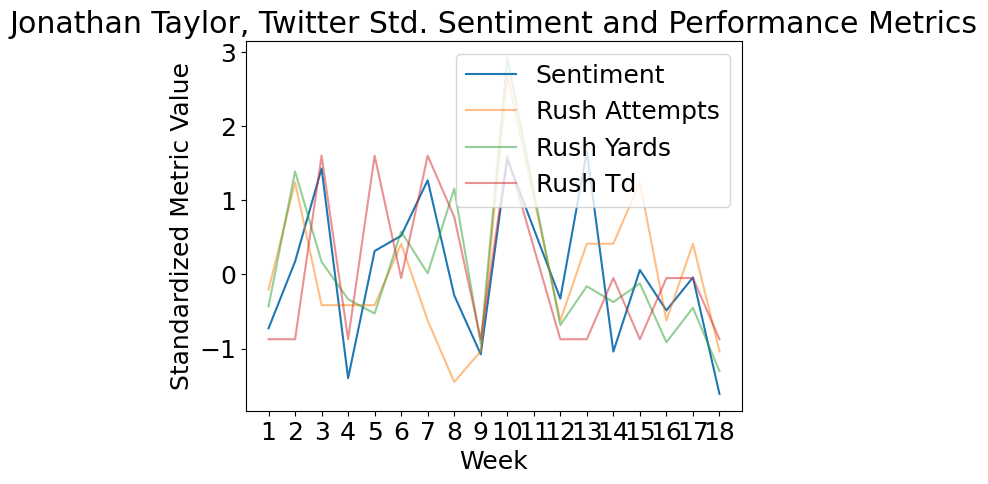

In [182]:
taylor_twitter_df, taylor_global_df, taylor_perf_df = get_dfs_for_player('Jonathan Taylor', rb_cols)
# taylor_twitter_df = taylor_twitter_df[~taylor_twitter_df['game_id'].isin([18])] 
taylor_global_df = taylor_global_df[~taylor_global_df['game_id'].isin([11])]   # Colts bye W11
taylor_twitter_df_std, taylor_global_df_std, taylor_perf_df_std = standardize_cols(taylor_twitter_df, taylor_global_df, taylor_perf_df, rb_cols)
make_plot(taylor_twitter_df_std, taylor_perf_df_std, 'Jonathan Taylor, Twitter')

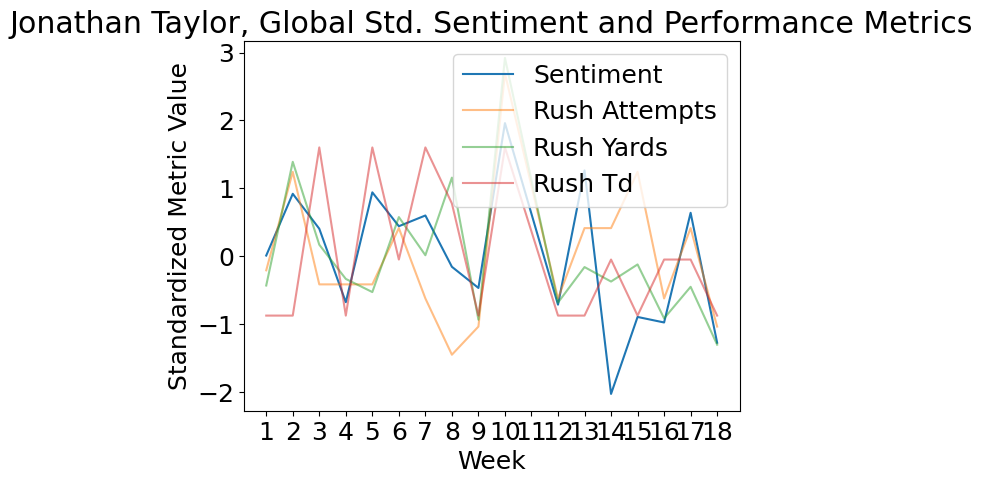

In [183]:
make_plot(taylor_global_df_std, taylor_perf_df_std, 'Jonathan Taylor, Global')

In [184]:
taylor_twitter_corr_df = get_corr_df(taylor_twitter_df, taylor_perf_df, rb_cols.copy(), rb_stats_list, 'Twitter')
taylor_global_corr_df = get_corr_df(taylor_global_df, taylor_perf_df, rb_cols.copy(), rb_stats_list, 'Global')
taylor_corr_df = pd.merge(taylor_twitter_corr_df, taylor_global_corr_df, on='Statistic')
taylor_corr_df

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,0.4622,0.4789,0.4684,0.4631,0.4268,0.5093
1,Rush Yards,0.5618,0.6569,0.5879,0.6315,0.5172,0.6085
2,Rush TDs,0.5884,0.5208,0.6018,0.4609,0.3713,0.5156


## Lagged Performance

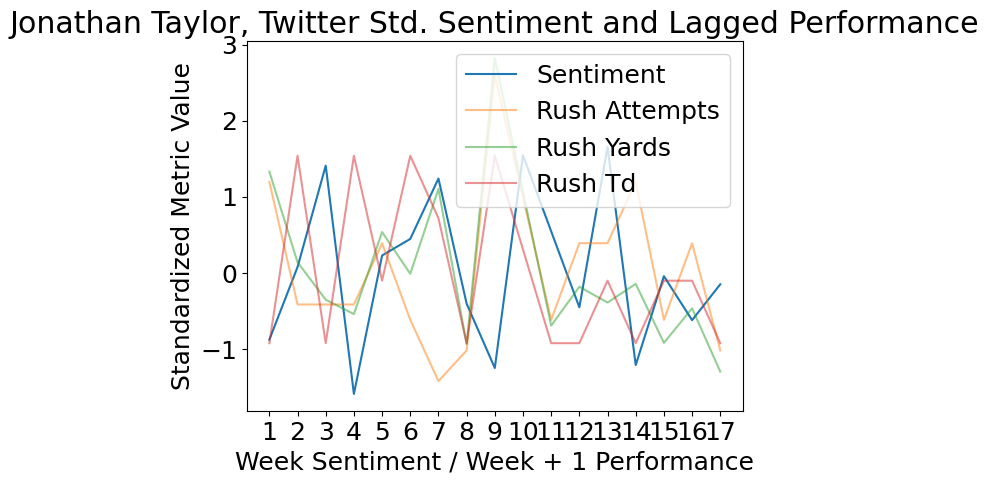

In [185]:
# Remove last row of sentiment and first row of performance
taylor_twitter_lag = taylor_twitter_df.iloc[:-1]
taylor_global_lag = taylor_global_df.iloc[:-1]
taylor_perf_lag = taylor_perf_df.iloc[1:]
taylor_twitter_lag_std, taylor_global_lag_std, taylor_perf_lag_std = standardize_cols(taylor_twitter_lag, taylor_global_lag, taylor_perf_lag, rb_cols)
make_lagged_plot(taylor_twitter_lag_std, taylor_perf_lag_std, 'Jonathan Taylor, Twitter')

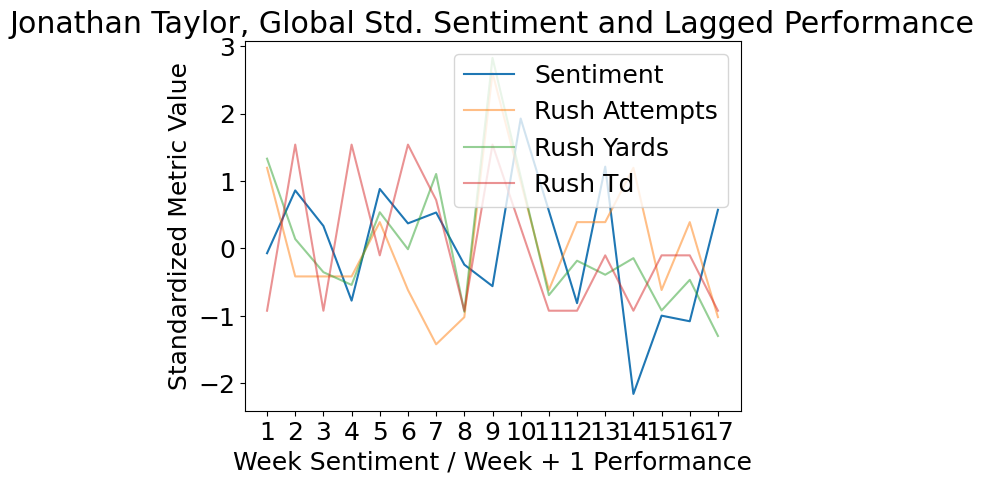

In [186]:
make_lagged_plot(taylor_global_lag_std, taylor_perf_lag_std, 'Jonathan Taylor, Global')

In [187]:
taylor_twitter_corr_lag = get_corr_df(taylor_twitter_lag, taylor_perf_lag, rb_cols.copy(), rb_stats_list, 'Twitter')
taylor_global_corr_lag = get_corr_df(taylor_global_lag, taylor_perf_lag, rb_cols.copy(), rb_stats_list, 'Global')
taylor_corr_lag = pd.merge(taylor_twitter_corr_lag, taylor_global_corr_lag, on='Statistic')
taylor_corr_lag

,Statistic,Twitter Pearson,Twitter Spearman,Twitter Distance Corr,Global Pearson,Global Spearman,Global Distance Corr
0,Rush Attempts,-0.4868,-0.4627,0.5446,-0.3820,-0.3209,0.4468
1,Rush Yards,-0.2119,-0.1029,0.3679,-0.0402,0.0618,0.3414
2,Rush TDs,-0.1668,-0.0624,0.3017,0.0398,0.0624,0.2343


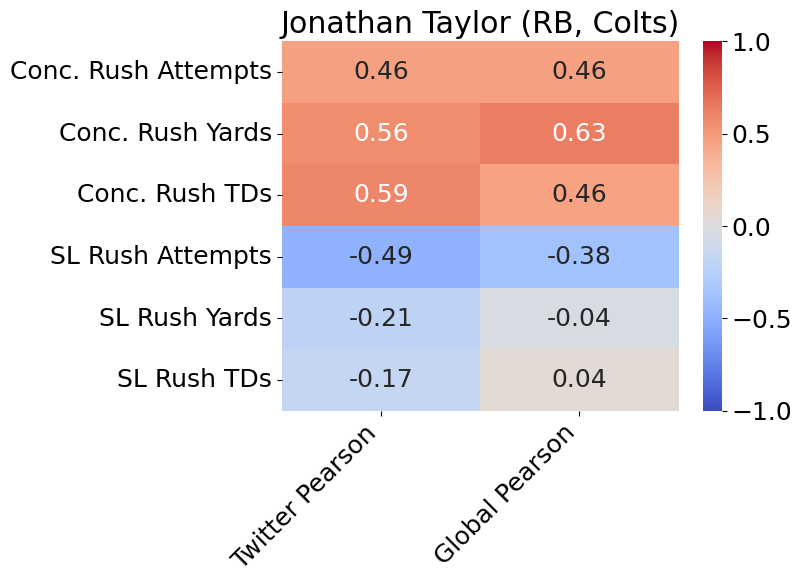

In [188]:
taylor_corr_df['Statistic'] = taylor_corr_df.apply(
    lambda row: 'Conc. ' + row['Statistic'], axis=1
)
taylor_corr_df = taylor_corr_df.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

taylor_corr_lag['Statistic'] = taylor_corr_lag.apply(
    lambda row: 'SL ' + row['Statistic'], axis=1
)
taylor_corr_lag = taylor_corr_lag.drop(columns=['Twitter Spearman', 'Global Spearman', 'Twitter Distance Corr', 'Global Distance Corr'])

taylor_corr_df = pd.concat([taylor_corr_df, taylor_corr_lag], ignore_index=True)

sns.heatmap(taylor_corr_df.set_index('Statistic'), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('Jonathan Taylor (RB, Colts)')
plt.ylabel('')
plt.show()

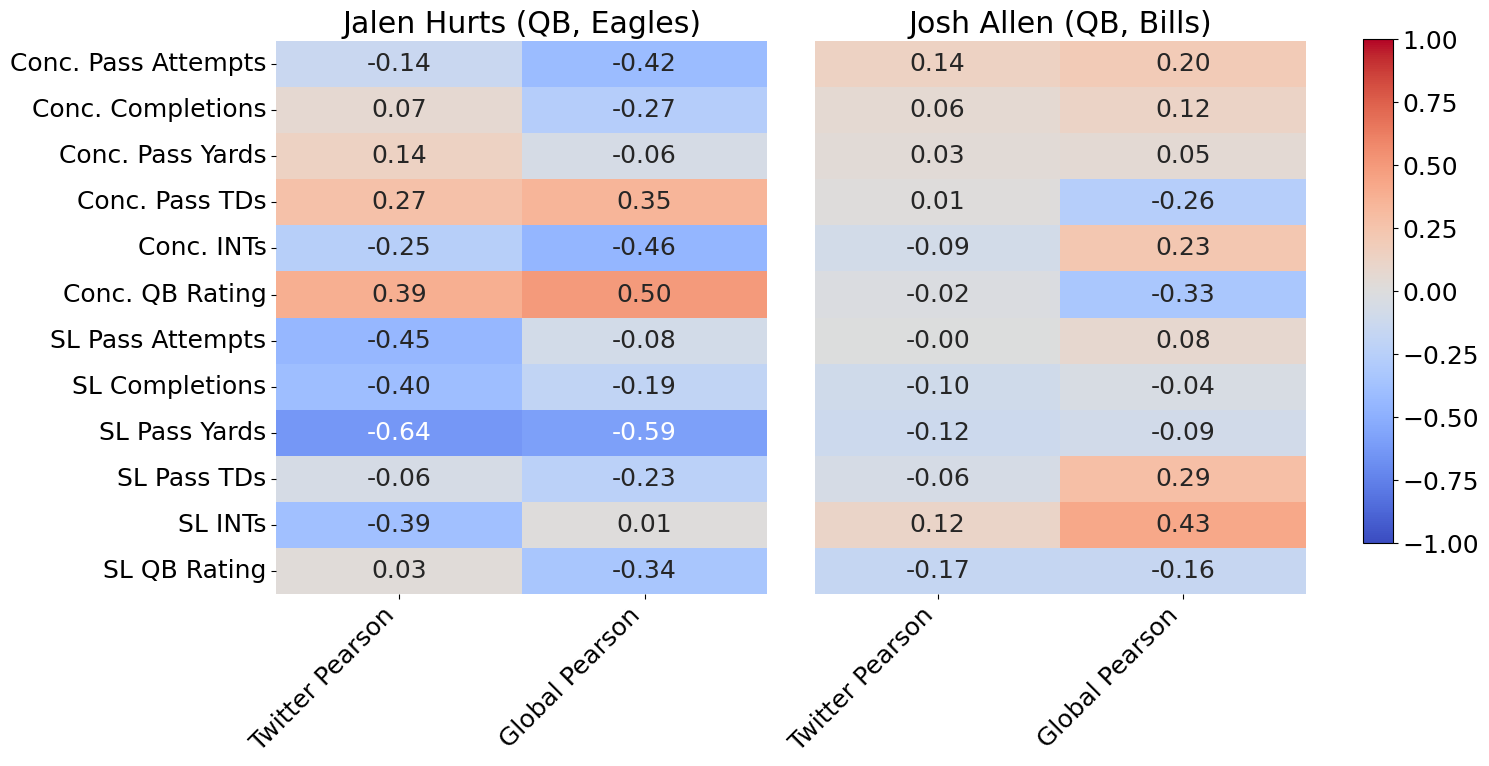

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Create heatmaps without colorbars
hm1 = sns.heatmap(
    hurts_corr_df.set_index('Statistic'),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', annot=True, cbar=False, ax=axes[0]
)

hm2 = sns.heatmap(
    allen_corr_df.set_index('Statistic'),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', annot=True, cbar=False, ax=axes[1]
)

# Add a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.63])  # [left, bottom, width, height]
fig.colorbar(hm1.collections[0], cax=cbar_ax)

# Titles and formatting
axes[0].set_title('Jalen Hurts (QB, Eagles)')
axes[1].set_title('Josh Allen (QB, Bills)')
axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels([])
axes[1].tick_params(axis='y', left=False)  # optional: removes tick marks too

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.show()

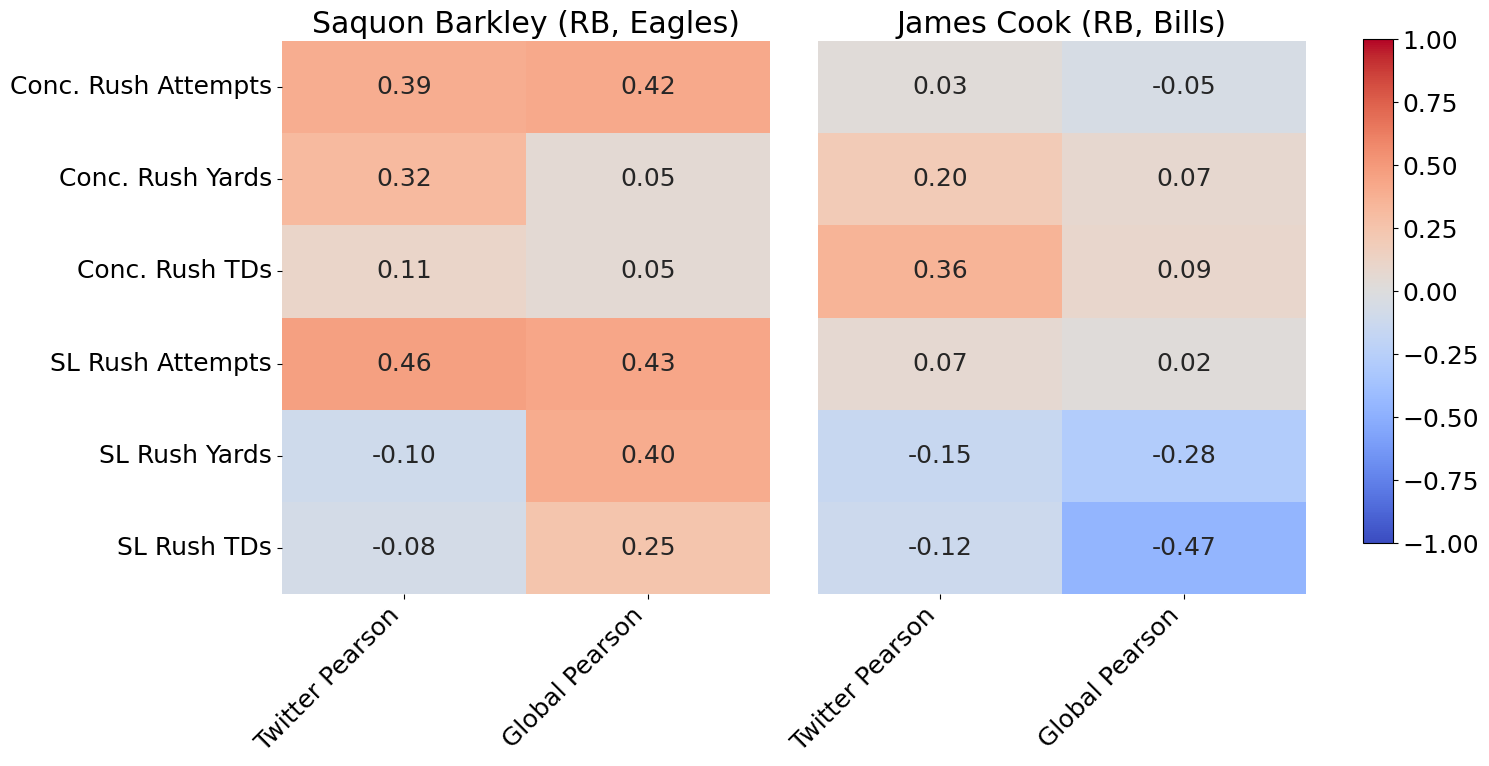

In [190]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Create heatmaps without colorbars
hm1 = sns.heatmap(
    barkley_corr_df.set_index('Statistic'),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', annot=True, cbar=False, ax=axes[0]
)

hm2 = sns.heatmap(
    cook_corr_df.set_index('Statistic'),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    fmt='.2f', annot=True, cbar=False, ax=axes[1]
)

# Add a single shared colorbar
cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.63])  # [left, bottom, width, height]
fig.colorbar(hm1.collections[0], cax=cbar_ax)

# Titles and formatting
axes[0].set_title('Saquon Barkley (RB, Eagles)')
axes[1].set_title('James Cook (RB, Bills)')
axes[0].set_ylabel('')
axes[1].set_ylabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels([])
axes[1].tick_params(axis='y', left=False)  # optional: removes tick marks too

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
plt.show()